In [2]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold, train_test_split
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import shap
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [3]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

### 1.1 Execution des expériences

In [5]:
features_ground_truth = ['block_reel_u', 'block_reel_v','same_block_reel', "dist_reelle", "proba_lien_reelle"]
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u',
                      'sp', 
                      'jc', 'aa', 'cn',
                      'dc_v']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]

experiments = {
    #"Ground_Truth_Only": features_ground_truth,
    "Structure_Only": features_structure,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    "Structure + Inferred_Commu": features_structure + features_commu_inferee,
    "Structure + Embeddings": features_structure + features_embeddings,
    "Full_features": features_structure + features_commu_inferee + features_embeddings
}

all_results = []
G_name = "reel_Airports"
G_obj = load_graphml_safe("graph_library/reel_Airports.graphml")

#for i in [0.00,1.00]:
for i in np.arange(0.00, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name_graph = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    G_obj = load_json(f"graph_library/{G_name_graph}.json")

    # 2. Injection de la vérité terrain
    #dataset_train = gp.enrich_dataset_with_ground_truth(dataset_train, G_obj, p_intra=0.6, q_inter=0.1)
    #dataset_eval = gp.enrich_dataset_with_ground_truth(dataset_eval, G_obj, p_intra=0.6, q_inter=0.1)

    pre_calculated_folds = gput._prepare_precalculated_folds(G_train, k=1)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f" Running: {exp_name} for SBM={i}")
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=50)
        
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list,
                                                                          parameters = Params, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        probs = model.predict_proba(X_test)[:, 1]
        preds = model.predict(X_test)

        if exp_name == "Ground_Truth_Only":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = dataset_eval[feat_list] 
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, dataset_eval["target"], "EXP_")
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC-ROC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC-ROC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

print("\n" + "="*50)
print("RÉCAPITULATIF DES EXPÉRIENCES (SBM vs Ground Truth)")
print("="*50)

# On affiche sans l'index pour plus de clarté si tu as déjà une colonne 'exp_name'
print(df_compare.to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

print("="*50 + "\n")

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_vs_gt.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

✅ Graphe chargé : 3363 nœuds et 13547 liens.
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
Graphe chargé : 362 nœuds et 1966 liens.
[K-FOLD] Préparation de 1 folds en parallèle...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


--- Démarrage Parallèle Fold 1 ---
Graphe original: 1202 liens
Graphe d'entraînement: 1021 liens
Liens cachés pour le test: 181

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 4):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 1):   8%|▊         | 2/25 [00:00<00:03,  6.12it/s]


Generating walks (CPU: 2):   8%|▊         | 2/25 [00:00<00:04,  5.39it/s]


Generating walks (CPU: 1):  12%|█▏        | 3/25 [00:00<00:04,  4.57it/s]

Generating walks (CPU: 2):  12%|█▏        | 3/25 [00:00<00:05,  3.92it/s]


Generating walks (CPU: 1):  16%|█▌        | 4/25 [00:00<00:05,  3.93it/s]

Generating walks (CPU: 3):  16%|█▌        | 4/25 [00:01<00:06,  3.12it/s]


Generating walks (CPU: 2):  16%|█▌        | 4/25 [00:01<00:07,  2.76it/s]


Generating walks (CPU: 2):  20%|██        | 5/25 [00:01<00:06,  2.89it/s]

Generating walks (CPU: 1):  28%|██▊       | 7/25 [00:01<00:05,  3.31it/s]


Generating walks (CPU: 4):  28%|██▊       | 7/25 [00:01<00:05,  3.19it/s]

Generating walks (CPU: 3):  24%|██▍       

Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


...

Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 2):   8%|▊         | 2/25 [00:00<00:03,  6.08it/s]

Generating walks (CPU: 3):   8%|▊         | 2/25 [00:00<00:03,  6.00it/s]


Generating walks (CPU: 2):  12%|█▏        | 3/25 [00:00<00:05,  4.24it/s]

Generating walks (CPU: 2):  16%|█▌        | 4/25 [00:00<00:05,  3.73it/s]


Generating walks (CPU: 4):  12%|█▏        | 3/25 [00:00<00:07,  3.02it/s]

Generating walks (CPU: 1):  16%|█▌        | 4/25 [00:01<00:08,  2.60it/s]


Generating walks (CPU: 2):  20%|██        | 5/25 [00:01<00:06,  3.21it/s]

Generating walks (CPU: 2):  24%|██▍       | 6/25 [00:01<00:05,  3.50it/s]


Generating walks (CPU: 4):  20%|██        | 5/25 [00:01<00:06,  3.05it/s]

Generating walks (CPU: 2):  28%|██▊       | 7/25 [00:01<00:04,  3.69it/s]


Generating walks (CPU: 1):  24%|██▍       | 6/25 [00:02<00:08,  2.24it/s]

Generating walks (CPU: 1):  28%|██▊

Entraînement du modèle Skip-gram...

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2):   0%|          | 0/25 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/25 [00:00<?, ?it/s]


Generating walks (CPU: 2):   8%|▊         | 2/25 [00:00<00:03,  6.29it/s]


Generating walks (CPU: 4):   8%|▊         | 2/25 [00:00<00:03,  7.12it/s]

Generating walks (CPU: 2):  12%|█▏        | 3/25 [00:00<00:04,  4.43it/s]


Generating walks (CPU: 4):  12%|█▏        | 3/25 [00:00<00:06,  3.41it/s]

Generating walks (CPU: 2):  16%|█▌        | 4/25 [00:00<00:05,  3.73it/s]

Generating walks (CPU: 1):  20%|██        | 5/25 [00:01<00:06,  3.17it/s]

Generating walks (CPU: 3):  20%|██        | 5/25 [00:01<00:06,  3.25it/s]


Generating walks (CPU: 2):  24%|██▍       | 6/25 [00:01<00:06,  2.91it/s]


Generating walks (CPU: 4):  20%|██        | 5/25 [00:01<00:08,  2.37it/s]

Generating walks (CPU: 2):  28%|██▊       | 7/25 [00:02<00:06,  2.96it/s]

Generating walks (CPU: 3):  28%|██▊       | 7/25 [00:02<00:06,  2.86it/s]


Generating walks (CPU: 2):  32%|███

KeyboardInterrupt: 

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

Graphique sauvegardé ici : outputs/plots/artificial_graphs_v2_comparaison_AUC-ROC_eval_per_SBM_ratio.png


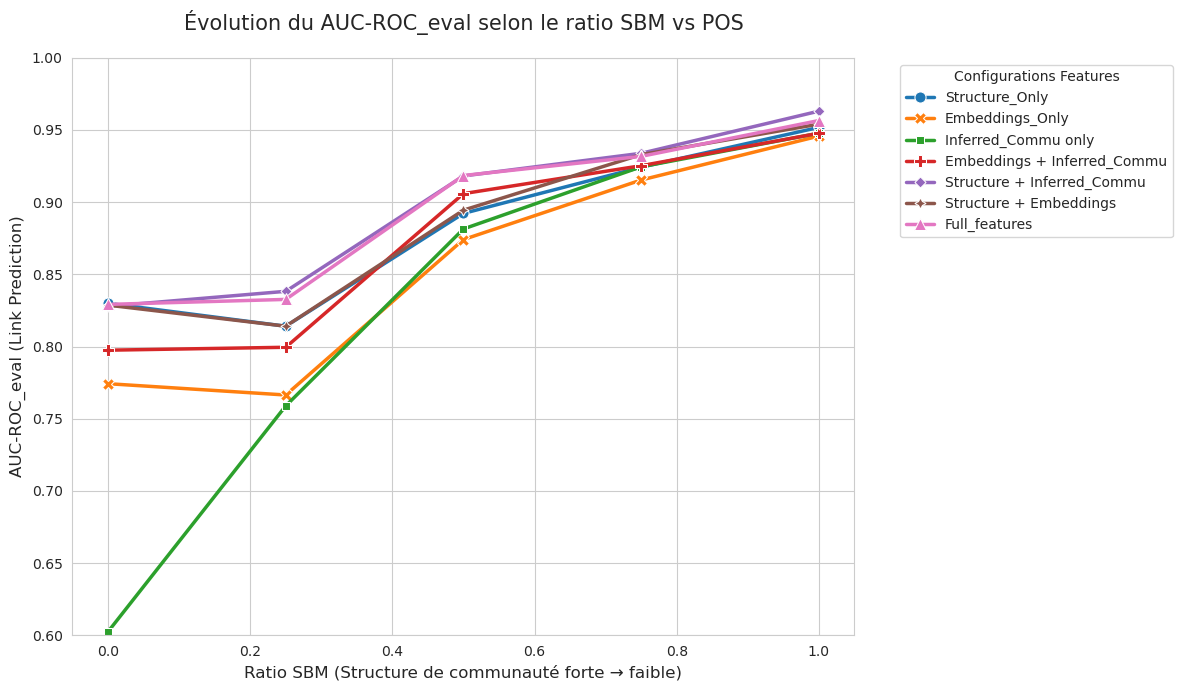

In [8]:
def plot_f1_comparison(df_results, metric="F1-Score"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.60, 1.00) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"artificial_graphs_v2_comparaison_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

df_compare = pd.read_csv("outputs/results/comparaison_finale_structure_vs_gt_v2_20260311.csv")

plot_f1_comparison(df_compare, metric="AUC-ROC_eval" )

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [72]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

Taux de liens réels (p) au sein d'un bloc :
Sans voisins communs : 0.9848
Avec voisins communs : 0.9791
--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
Taux réel quand CN = 0 : 0.9420
Taux réel quand CN > 0 : 0.8966
--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
    mean  count
sp             
1  1.000   2888
2  0.875    570
3  0.857      7

Taux réel quand SP = 0 (aucun chemin) : nan
Taux réel quand SP > 0 (chemin existe) : 0.8974

============= DEEP DIVE PERFORMANCE : GT Only ==============
Nombre total de paires : 7700
------------------------------------------------------------
VRAIS POSITIFS (TP) : 708
  ├─ Intra-bloc : 708 | Inter-bloc : 0
  └─ Dont déjà connus (SP=1) : 603 (85.2%)
  └─ Trouvés par intelligence (SP!=1) : 105
------------------------------------------------------------
FAUX POSITIFS (FP) : 10
  ├─ Intra-bloc : 10 (Confusion même bloc)
  ├─ Inter-bloc : 0 (Erreur sur

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_11338/2678378530.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()


### 1.4 plots des AP curves

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

ValueError: continuous-multioutput format is not supported

<Figure size 1000x700 with 0 Axes>

### 1.5 Analyse de variance de probas prédites

In [104]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)


=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===
                          Type       Modèle  Variance  Valeurs Uniques  Moyenne
  Intra-Bloc (Même communauté) Ground Truth     0.001              570    0.977
  Intra-Bloc (Même communauté)    Structure     0.088              679    0.104
Inter-Bloc (Communautés diff.) Ground Truth     0.000             5705    0.003
Inter-Bloc (Communautés diff.)    Structure     0.077             4654    0.089


### 1.5 Analyse des communautés inférées

In [99]:
def compute_agreement_ratio(X_test, dataset, algo_col='same_infomap'):
    """
    Calcule le pourcentage de paires où l'inférence est d'accord avec la GT.
    """
    # 1. On récupère la vérité terrain
    y_true = dataset.loc[X_test.index, 'same_block_reel']
    y_inf  = X_test[algo_col]
    
    # 2. On compare
    agreement = (y_true == y_inf).mean()
    
    print(f"Ratio d'accord entre {algo_col} et la réalité : {agreement:.2%}")
    
    # Détail pour ton chercheur :
    # Combien de fois l'algorithme a vu une communauté là où il n'y en a pas (Faux Positifs de structure)
    over_detection = ((y_inf == 1) & (y_true == 0)).sum()
    print(f"  └─ Paires vues 'ensemble' par erreur : {over_detection}")
    
    return agreement

def count_inferred_communities(dataset, algo_prefix='infomap'):
    """
    Compte le nombre de clusters uniques trouvés par un algorithme.
    Ex: algo_prefix='infomap' ira chercher 'infomap_u' et 'infomap_v'.
    """
    col_u = f"{algo_prefix}_u"
    col_v = f"{algo_prefix}_v"
    
    if col_u in X_test.columns and col_v in X_test.columns:
        # On combine les deux colonnes et on compte les valeurs uniques
        all_commus = pd.concat([X_test[col_u], X_test[col_v]])
        n_unique = all_commus.nunique()
        print(f"Nombre de communautés uniques ({algo_prefix}) : {n_unique}")
        return n_unique
    else:
        print(f"Colonnes pour {algo_prefix} introuvables.")
        return None

# Utilisation
n_infomap = count_inferred_communities(dataset, 'infomap')
ratio = compute_agreement_ratio(X_test_s, dataset, 'same_infomap')

Nombre de communautés uniques (infomap) : 100
Ratio d'accord entre same_infomap et la réalité : 100.00%
  └─ Paires vues 'ensemble' par erreur : 0


### 1.6 Exploration visuelle des positions et catégories

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


NameError: name 'PROJECT_ROOT' is not defined

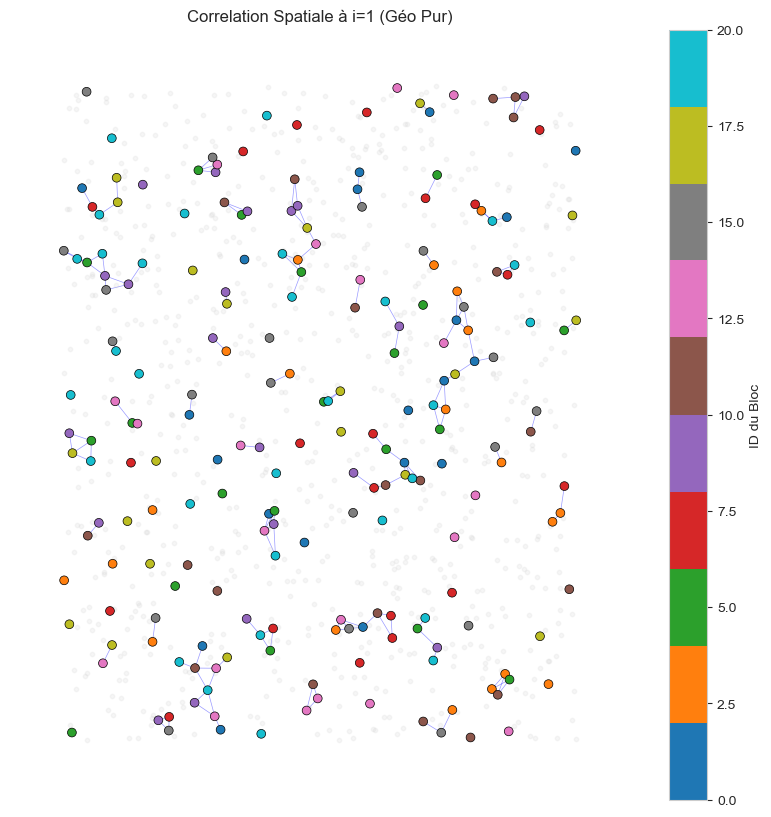

In [81]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Evaluation perfs sur echantillon plus large - OBSOLETE

In [79]:
def generate_extended_eval_data(G, initial_pairs_df, expansion_factor=50, concat = True):
    nodes_list = list(G.nodes())
    num_initial = len(initial_pairs_df)
    target_extra = num_initial * expansion_factor

    existing_pairs = set()
    for u, v in zip(initial_pairs_df['u'], initial_pairs_df['v']):
        existing_pairs.add(tuple(sorted((u, v))))

    extra_pairs_list = []
    current_extra_set = set() 
    
    while len(extra_pairs_list) < target_extra:
        batch_size = min(target_extra - len(extra_pairs_list), 50000)
        random_u = np.random.choice(nodes_list, size=batch_size)
        random_v = np.random.choice(nodes_list, size=batch_size)
        
        for u, v in zip(random_u, random_v):
            if u == v:
                continue
            
            pair = tuple(sorted((u, v)))
            
            if pair not in existing_pairs and pair not in current_extra_set:
                current_extra_set.add(pair)
                extra_pairs_list.append({'u': u, 'v': v, 'target': 0})
            
            if len(extra_pairs_list) >= target_extra:
                break

    extra_df = pd.DataFrame(extra_pairs_list)
    
    if concat: 
        full_df = pd.concat([initial_pairs_df, extra_df], ignore_index=True)
    else:
        full_df = extra_df

    full_df = add_ground_truth_groups(full_df, G)
    
    return full_df

def run_scaling_evaluation(G, base_dataset, experiments_dict, eval_data, factors=[10, 20, 30, 40, 50]):
    all_results = []
    
    for factor in factors:
        print(f"\n" + "="*50)
        print(f" TEST AVEC EXPANSION FACTOR : {factor}")
        print("="*50)
        
        # 1. Génération du dataset d'entraînement étendu
        extended_train_data = generate_extended_eval_data(G, base_dataset, expansion_factor=factor, concat=True)
        
        for exp_name, feat_list in experiments_dict.items():
            print(f"\n🔹 Expérience : {exp_name}")
            
            # 3. Entraînement et Test classique (sur le set étendu)
            stats_train, model, X_test_base, _, y_test_base, _ = gp.train_and_eval_xgboost(extended_train_data, features=feat_list)
            
            # 4. Evaluation
            X_eval_robust = pd.concat([eval_data[feat_list], X_test_base[feat_list]], ignore_index=True)
            y_eval_robust = pd.concat([eval_data["target"], y_test_base], ignore_index=True)
            
            eval_stats = gp.evaluate_model_performance(model, X_eval_robust, y_eval_robust)
            
            # 5. Stockage des résultats
            all_results.append({
                "Factor": factor,
                "Experiment": exp_name,
                "AUC-PR_Test": stats_train["AUC-PR"].iloc[0],
                "AUC-ROC_Eval": eval_stats["AUC-ROC"].iloc[0],
                "F1_Eval": eval_stats["F1-Score"].iloc[0]
            })
            
    return pd.DataFrame(all_results)

In [80]:
G_name = "artificial_graph_sbm_0_00_pos_1_00"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

dataset = dataset_raw[["u", "v", "target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_stress_test = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

experiments = {
    "Ground_Truth_Only_SG": ['same_group'],
    "Ground_Truth_Full": ['group_u', 'group_v', 'same_group'],
}

print(f"Lancement de l'évaluation multi-expériences...")
df_final_results = run_scaling_evaluation(
    G=G, 
    base_dataset=dataset, 
    experiments_dict=experiments, 
    eval_data=eval_stress_test, 
    factors= [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
)

print("\n Analyse terminée.")
print(df_final_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"ANALYSE_Scaling_Full_{G_name}.csv")
df_final_results.to_csv(save_path, index=False)
print(f"Résultats sauvegardés sous : {save_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3500 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib

--- TEST AVEC EXPANSION FACTOR : 0 ---
Modèle A (Same Group Only)...

 RÉSULTATS
[{'F1-Score': 0.9843304843304843, 'AUC-ROC': 0.9844839235811291, 'AP': 0.9833514976974892, 'AUC-PR': 0.9916351580908542}]

 RÉ

In [67]:
import os

# 1. Création du dossier de destination s'il n'existe pas
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)

# 2. Définition du nom du fichier
file_name = f"ANALYSE_EtudeFacteurRatioLiensNonLiens_{G_name}.csv"
file_path = os.path.join(output_dir, file_name)

# 3. Sauvegarde du DataFrame
df_final_results.to_csv(file_path, index=False)

print(f"✅ Dataset sauvegardé avec succès dans : {file_path}")

✅ Dataset sauvegardé avec succès dans : outputs/results/ANALYSE_EtudeFacteurRatioLiensNonLiens_artificial_graph_sbm_1_00_pos_0_00.csv


In [37]:
G_name = "artificial_graph_sbm_0_60_pos_0_40"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_sg = ['same_group']

dataset = dataset_raw[["u", "v","target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_dataset = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

dataset_extended_50 = generate_extended_eval_data(G, df_initial, expansion_factor=50, concat=False)
dataset_extended_10 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)
dataset_extended_20 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)

results =[]
print("DATASET DE BASE, SAME_GROUP ONLY : ")
stats_df, model_a, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth_sg)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })
X_eval = pd.concat([eval_dataset[features_ground_truth_sg], X_test[features_ground_truth_sg]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_a,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET DE BASE, W GROUPS ID : ")
stats_df, model_b, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

X_eval = pd.concat([eval_dataset[features_ground_truth], X_test[features_ground_truth]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_b,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET EXTENDED*50, W GROUPS ID : ")
stats_df, model_c, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset_e, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

"""
gp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])
"""

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3495 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_60_pos_0_40
 Taille : 6990 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
DATASET DE BASE, SAME_GROUP ONLY : 

 RÉSULTATS
[{'F1-Score': 0.5784313725490197, 'AUC-ROC': 0.7020746938976217, 'AP': 0.7099103007031315, 'AUC-PR': 0.8519782405744738}]

 RÉSULTATS D'ÉVALUATION
-------------

'\ngp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])\n'

## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [9]:
all_summaries = []

for i in np.arange(0, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    print(f"Type de l'objet : {type(shap_explainer)}")
    print(f"Dimensions des valeurs : {shap_explainer.values.shape}")

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


SHAP Analysis introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (394, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_25_pos_0_75.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (394, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_50_pos_0_50.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (402, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_75_pos_0_25.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (400, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_1_00_pos_0_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (398, 23)


### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_mean_shap.png


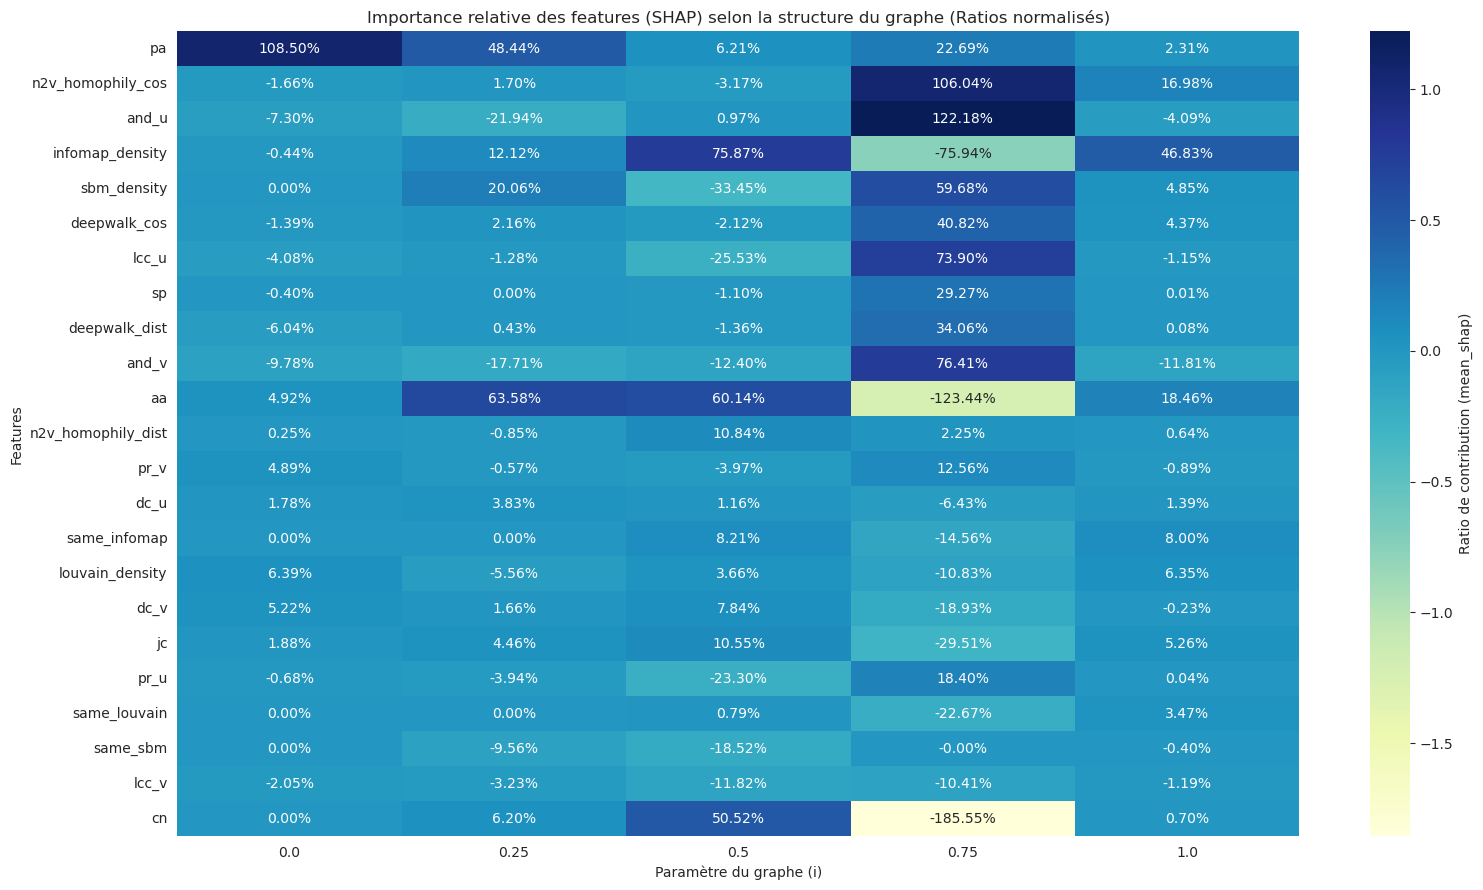

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr

'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_abs_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, 
                annot=True,       
                fmt=fmt_type,        
                cmap="YlGnBu",    
                cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_shap", as_ratio=True)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_0_00_pos_1_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_train_artificial_graph_sbm_0_00_pos_1_00
 Taille : 32725 lignes, 29 colonnes.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_eval_artificial_graph_sbm_0_00_pos_1_00
 Taille : 26775 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
SHAP Analysis introuvable pour artificial_gra

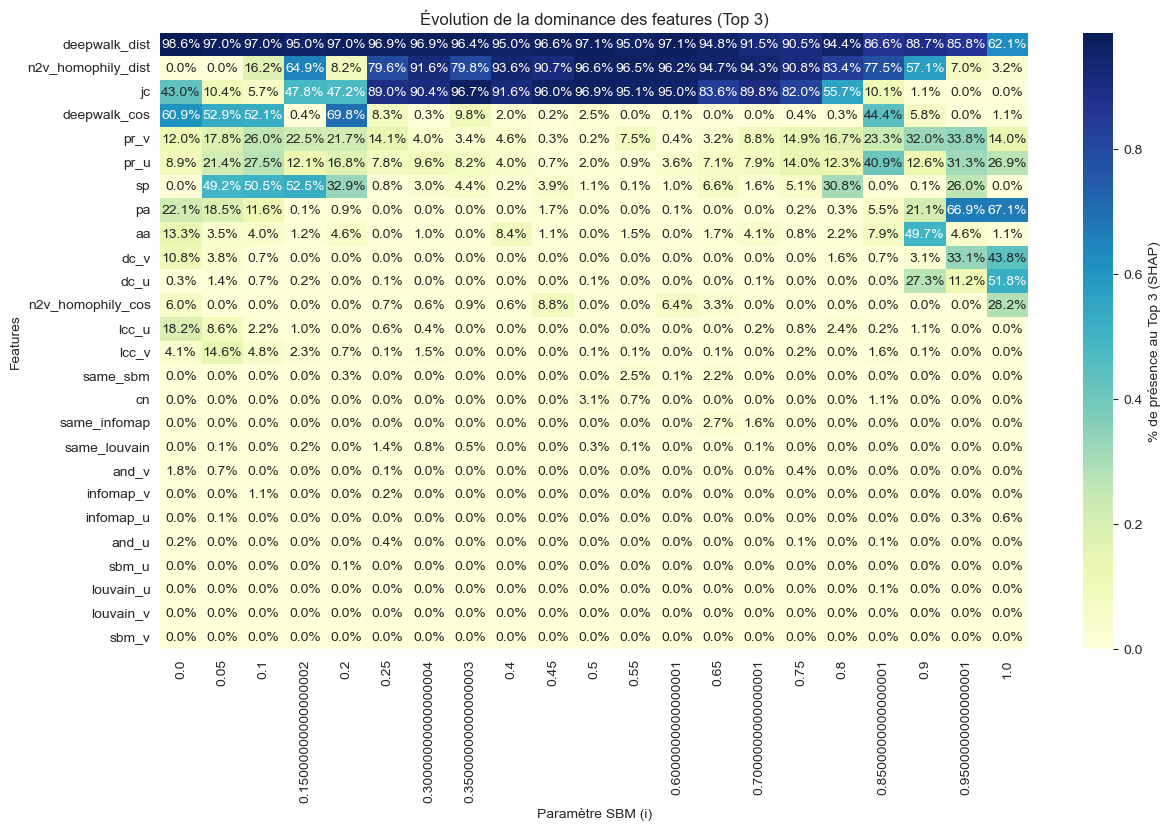

In [66]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

## 3 - Exploration des features et groupes de features

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


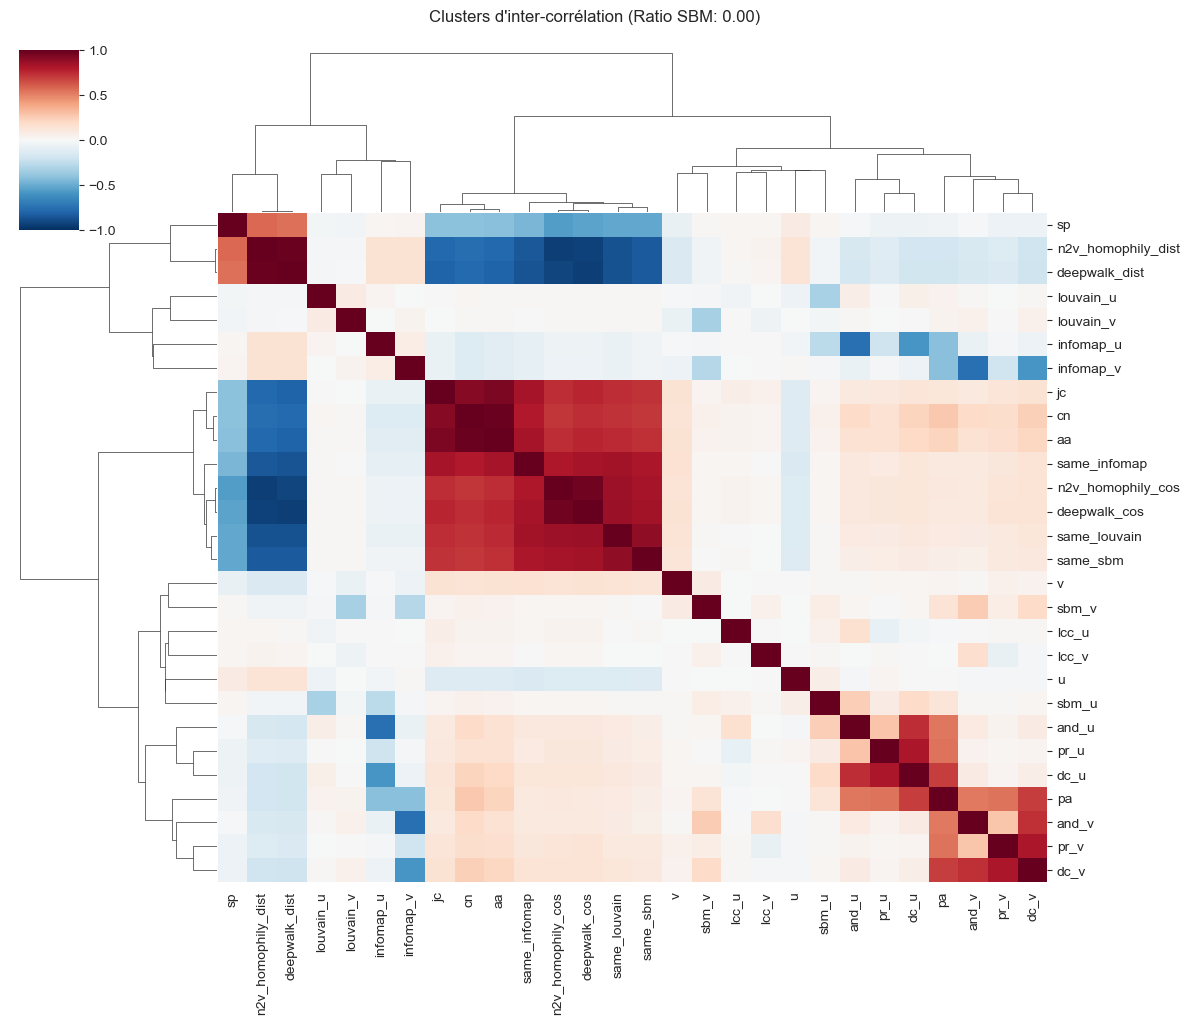

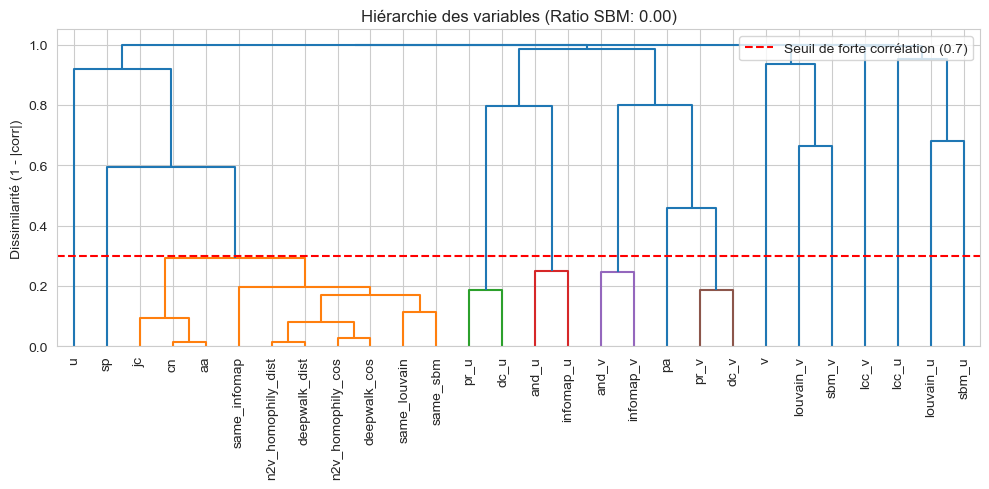

SHAP Analysis introuvable pour artificial_graph_sbm_0_25_pos_0_75.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_25.png


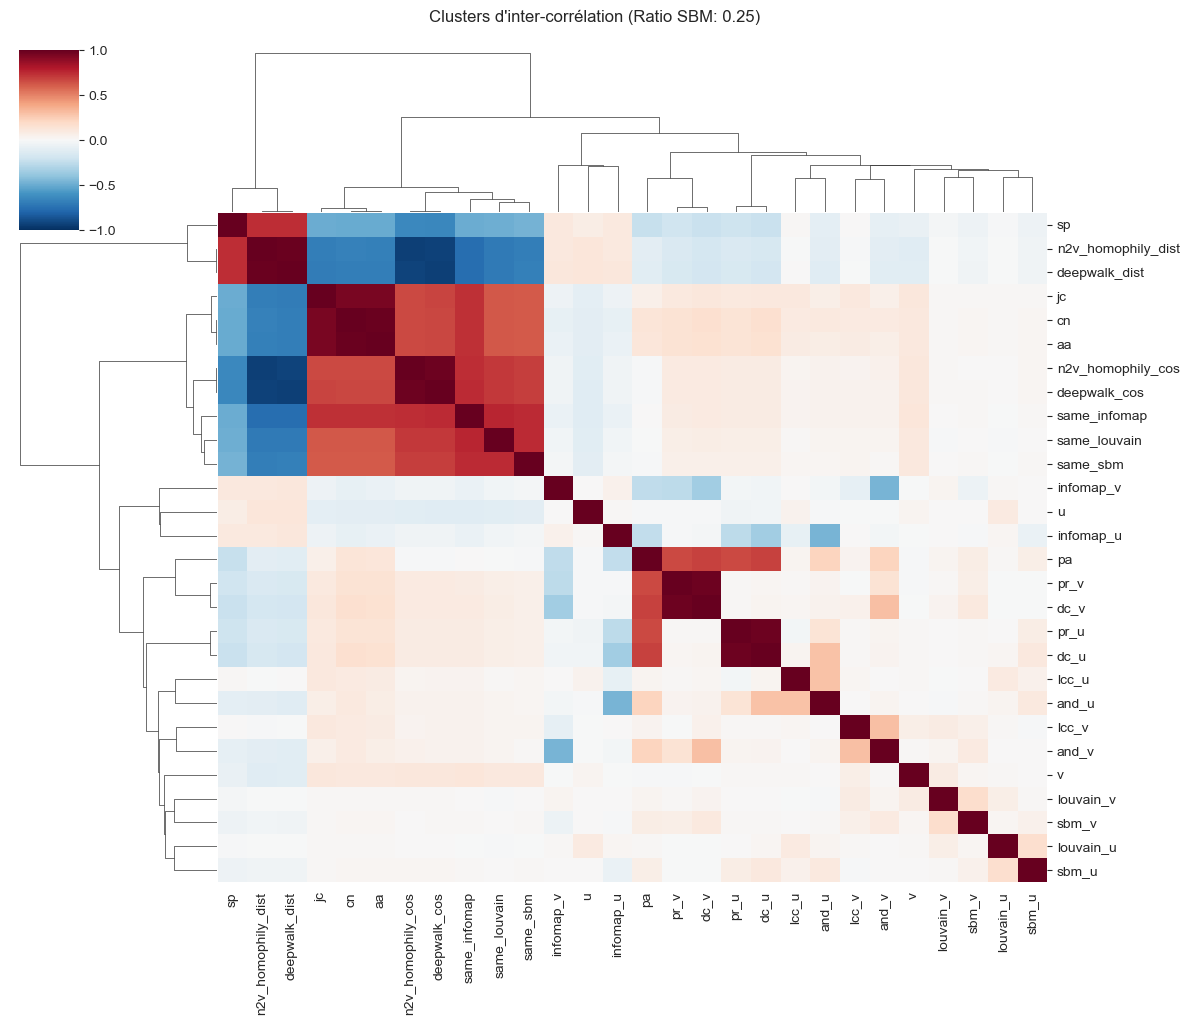

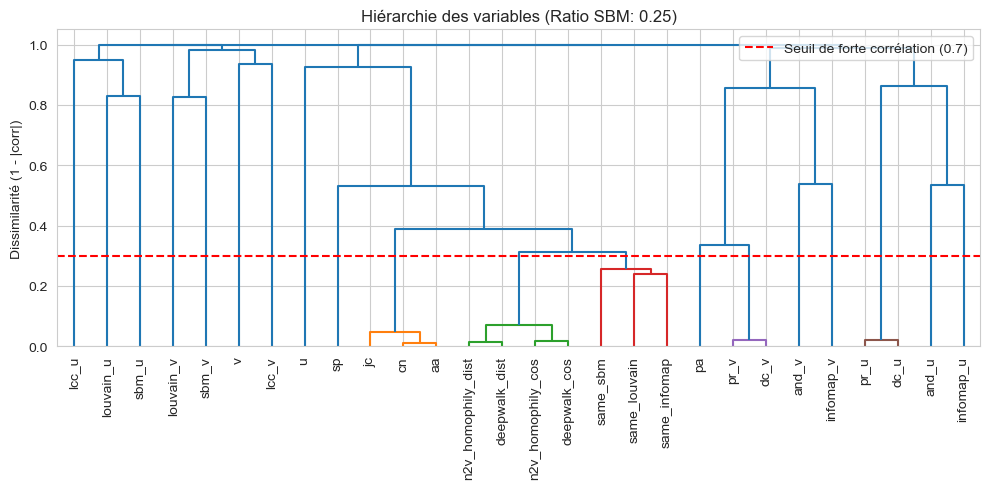

SHAP Analysis introuvable pour artificial_graph_sbm_0_50_pos_0_50.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_50.png


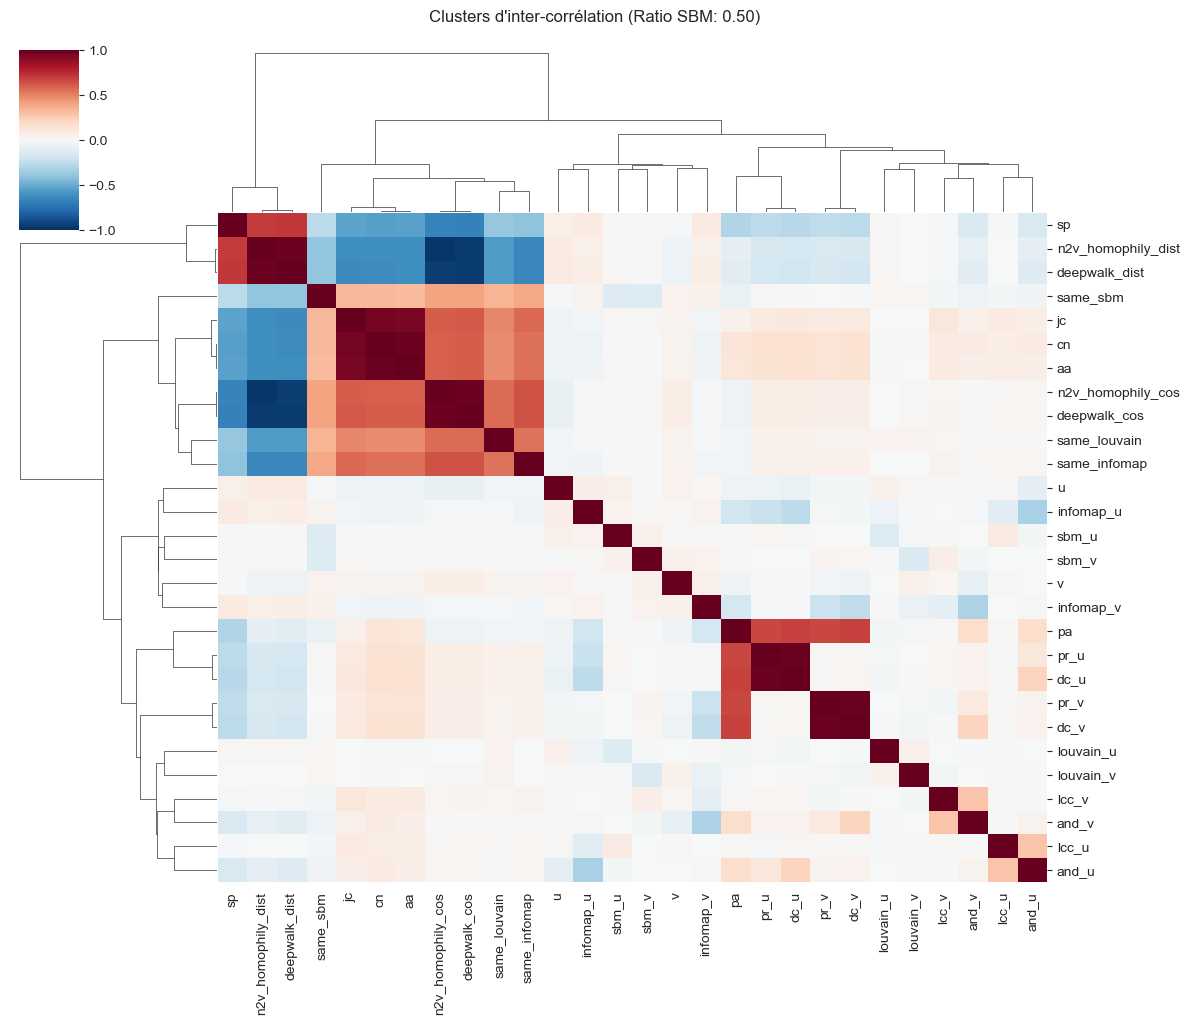

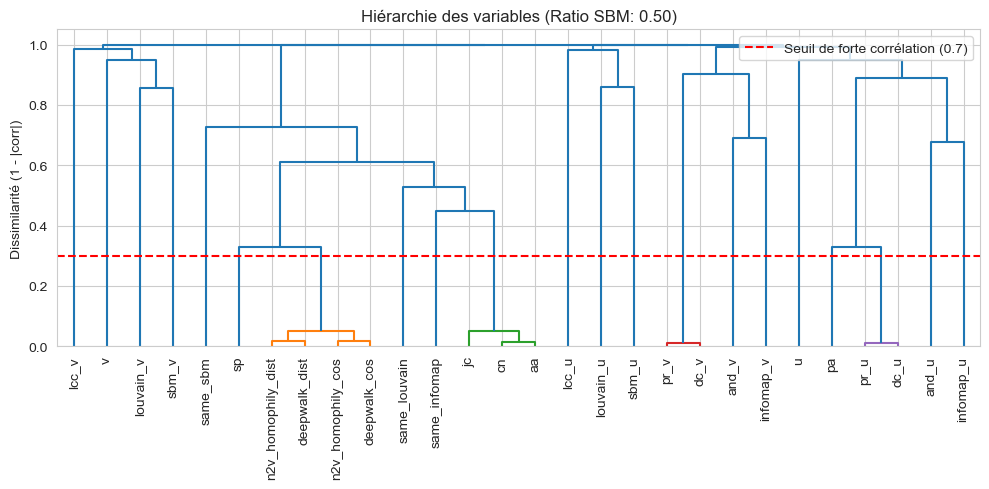

SHAP Analysis introuvable pour artificial_graph_sbm_0_75_pos_0_25.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_75.png


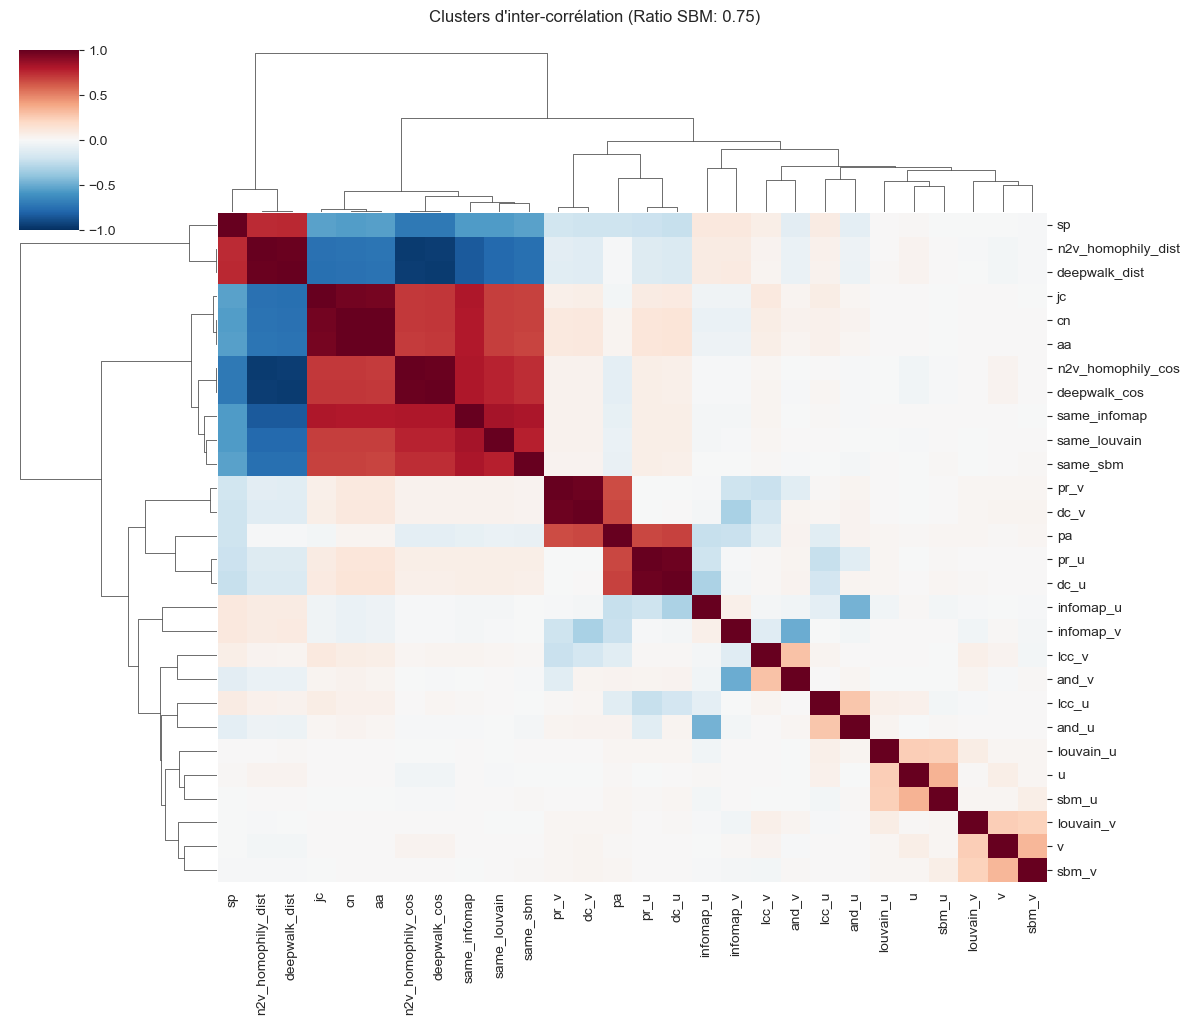

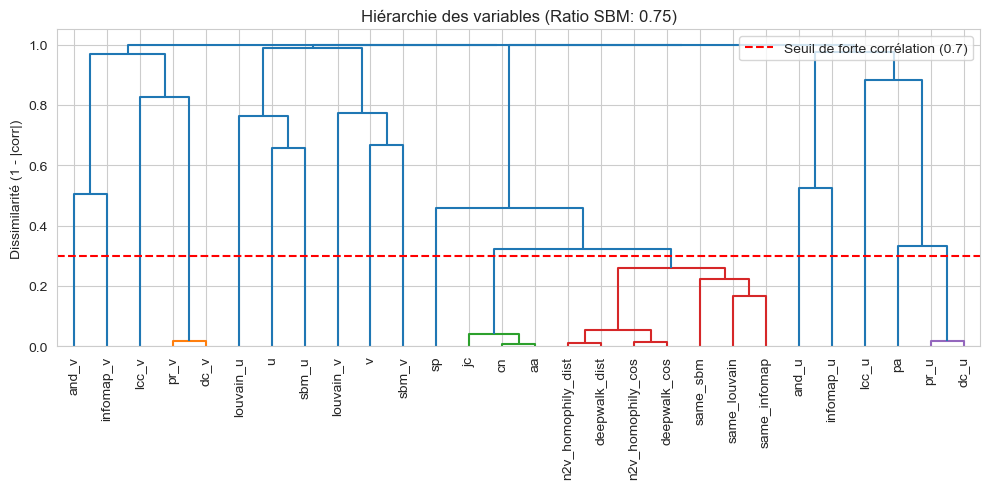

SHAP Analysis introuvable pour artificial_graph_sbm_1_00_pos_0_00.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_1_00.png


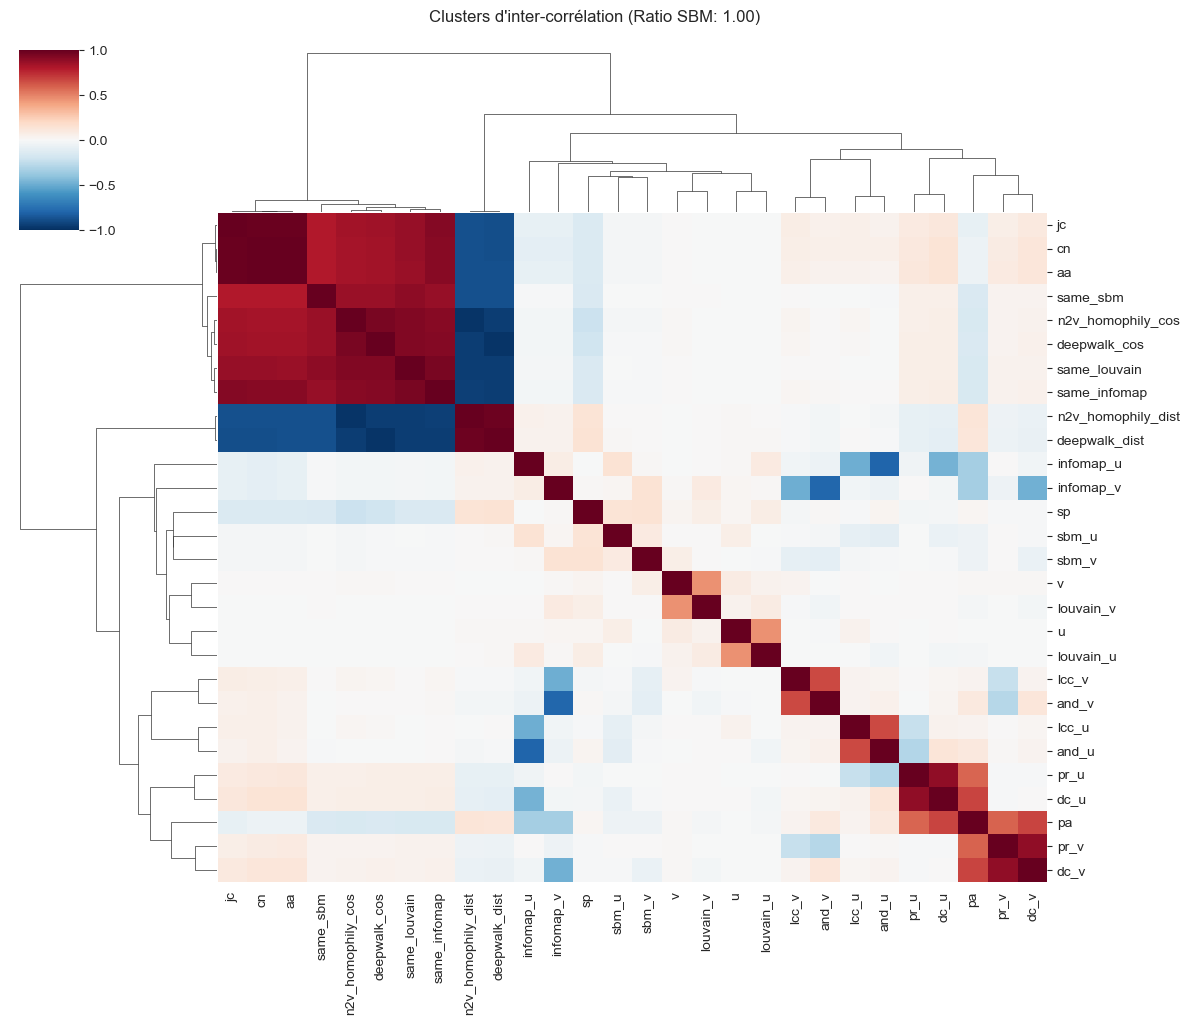

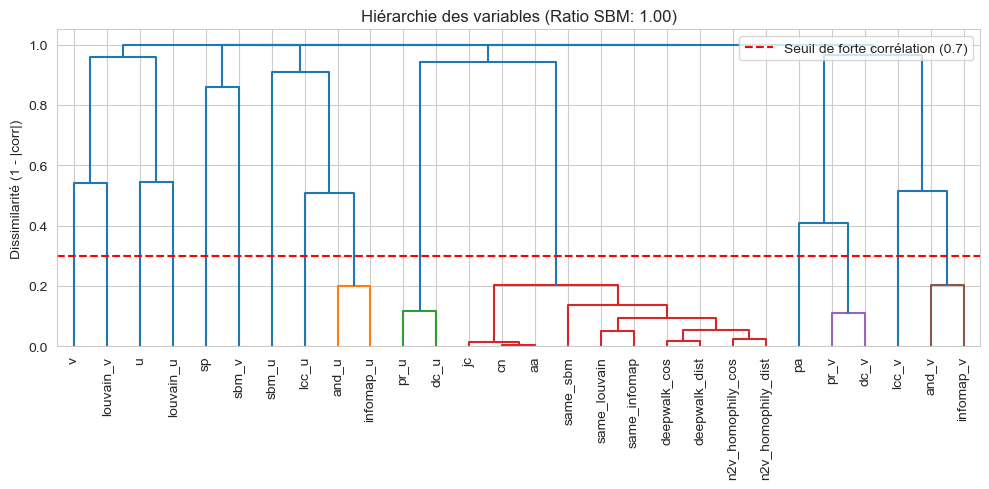

In [82]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_u', 'sbm_v', 'same_sbm', 'infomap_u', 'infomap_v', 'same_infomap', "louvain_u", "louvain_v", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = np.arange(0, 1.05, 0.25) # On réduit le pas pour les plots de clusters

for i in ratios:
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]
    
    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()


    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    # Distance = 1 - valeur absolue de la corrélation (pour regrouper corr+ et corr-)
    dissimilarity = 1 - np.abs(corr_matrix)
    # squareform pour transformer en vecteur de distance
    Z = hierarchy.linkage(squareform(dissimilarity), method='complete')
    
    hierarchy.dendrogram(Z, labels=features, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4 - Other

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


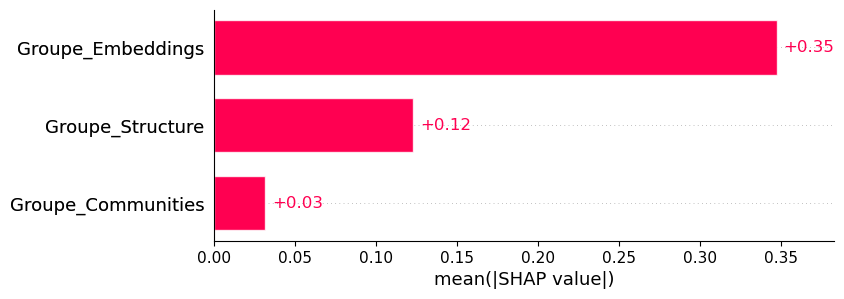


--- SHAP Bar Plot (Absolute) ---


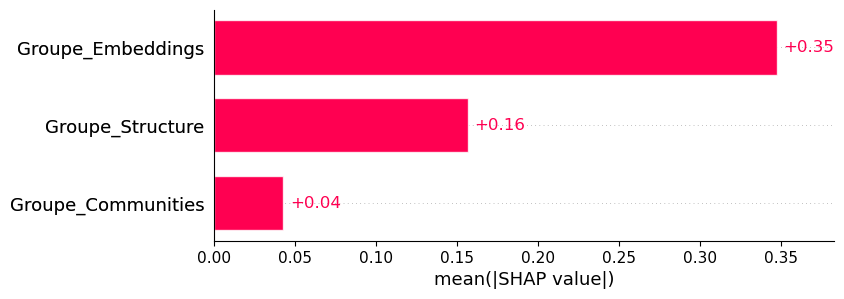


--- SHAP Custom Analysis ---


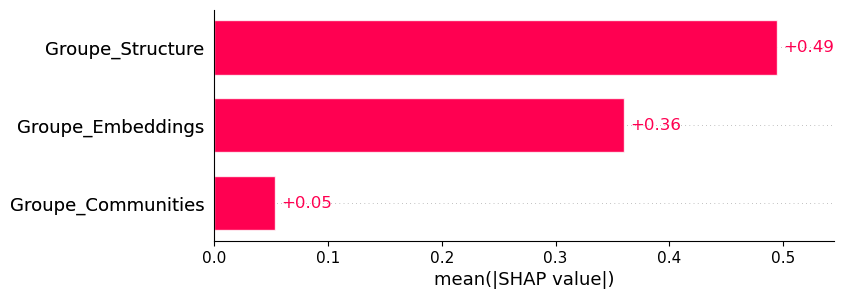


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


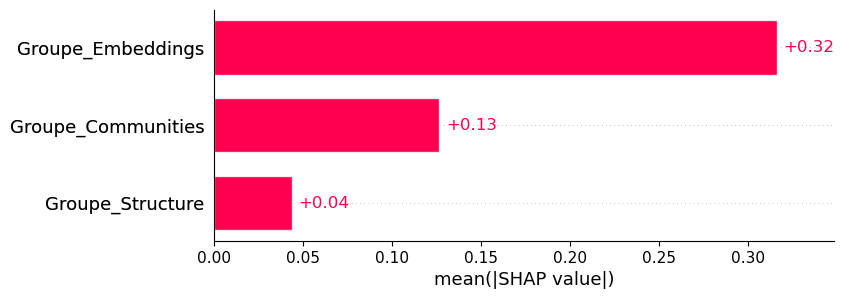


--- SHAP Bar Plot (Absolute) ---


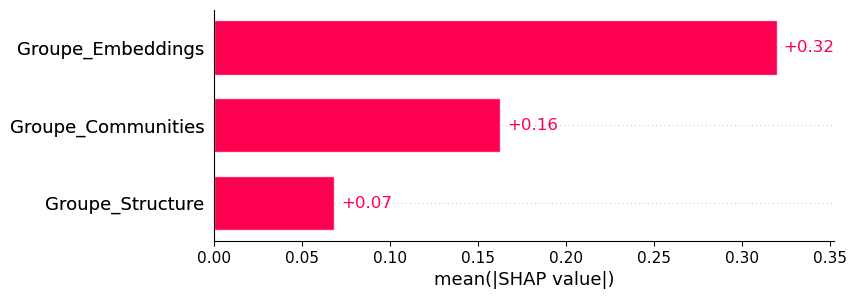


--- SHAP Custom Analysis ---


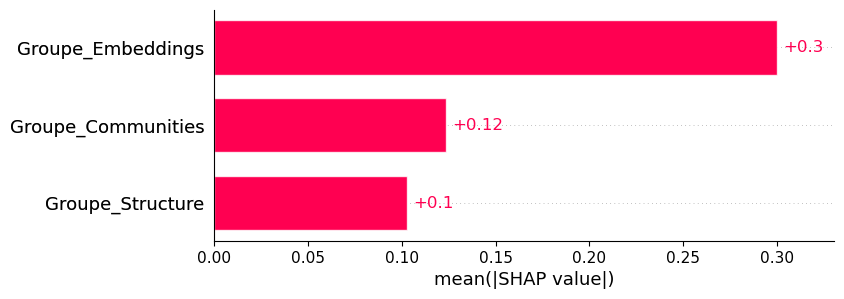


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
def xgboost_shap_pipeline(dataset, name):
    exclude = ['u', 'v', 'target', 'label']
    features = [col for col in dataset.columns if col not in exclude]
    
    results, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset, features=features)

    data_to_save = {
        "results": results,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "y_test": y_test,
        "y_train": y_train
    }

    print("Sauvegarde des données XGBoost (model,X1yTest et Train)")
    gp.loadsave_data_joblib(data=data_to_save,filename=f"xgboost_data_{name}.joblib", mode="save")

    print("\n RÉSULTATS")
    print(results.to_string(index=False))

    print("\n Shapley va ! Lu.")

    shap_explanation = gp.analyze_with_shap(model, X_test)
    print("Sauvegarde de l'analyse SHAP")
    gp.loadsave_data_joblib(data=shap_explanation, filename = f"shap_explainer_{name}.joblib", mode="save")

xgboost_shap_pipeline(dataset_sbm_1_true_groups, "TEST_W_REAL_GROUPS_SBM_1")
xgboost_shap_pipeline(dataset_sbm_0_5_true_groups, "TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


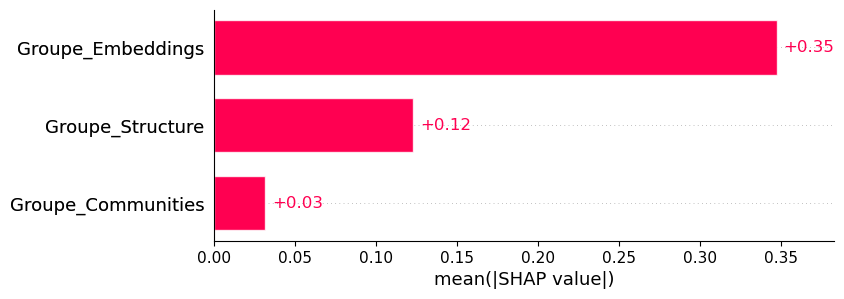


--- SHAP Bar Plot (Absolute) ---


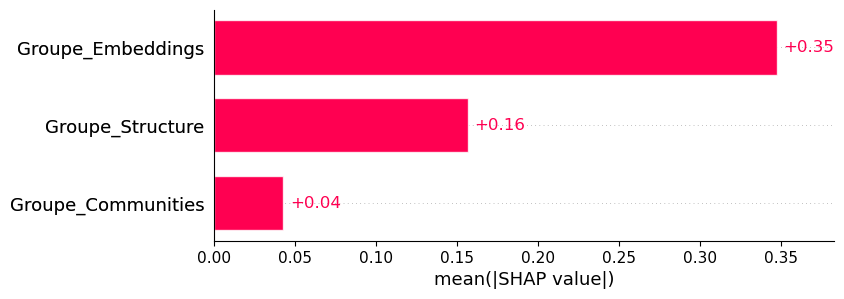


--- SHAP Custom Analysis ---


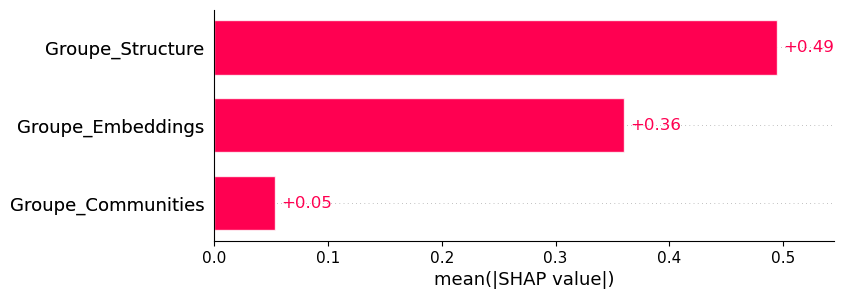


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


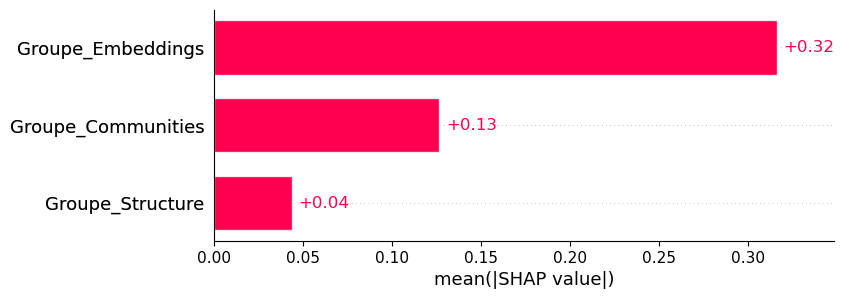


--- SHAP Bar Plot (Absolute) ---


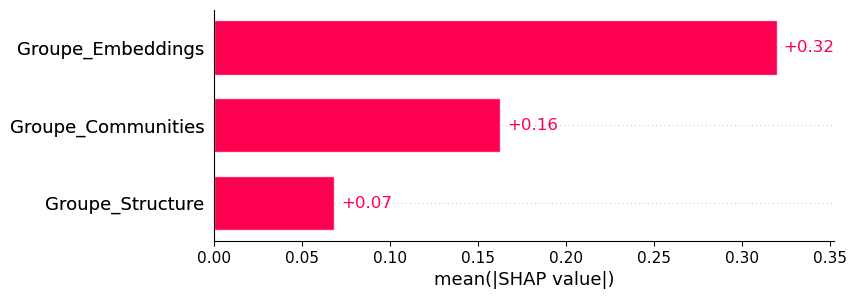


--- SHAP Custom Analysis ---


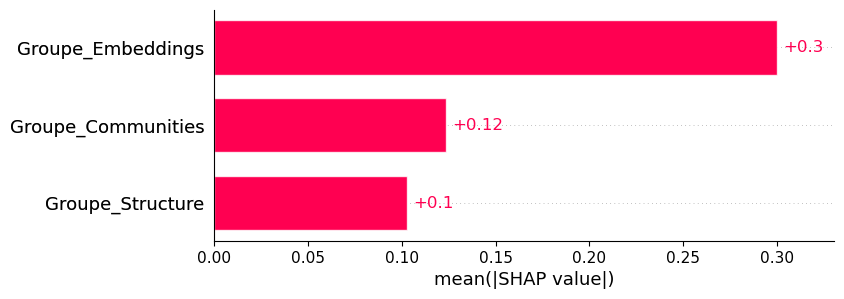


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
gp.evaluate("TEST_W_REAL_GROUPS_SBM_1", display = True)
gp.evaluate("TEST_W_REAL_GROUPS_SBM_0_5", display = True)

In [4]:
gp.display_shap("TEST_W_REAL_GROUPS_SBM_1")
gp.display_shap("TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib


1

In [30]:
dataset, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph("TEST_W_REAL_GROUPS_SBM_0_5")
dataset_base, xgboost_data_base, shap_explainer_base, shap_analysis_base = gp.load_all_data_for_graph("artificial_graph_sbm_0_50_pos_0_50")

gp.evaluate_model_performance(model = xgboost_data["model"], X_test = xgboost_data["X_test"], y_test = xgboost_data["y_test"], plot = False)
gp.evaluate_model_performance(model = xgboost_data_base["model"], X_test = xgboost_data_base["X_test"], y_test = xgboost_data_base["y_test"], plot = False)

print(dataset.head(2))
print(dataset_base.head(2))


dataset_cleared = dataset.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)
dataset_base_cleared = dataset_base.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)

print(dataset_cleared.head(2))
print(dataset_base_cleared.head(2))


all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_cleared)
all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_base)

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_TEST_W_REAL_GROUPS_SBM_0_5
 Taille : 6988 lignes, 23 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_50_pos_0_50
 Taille : 6988 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [43]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

all_results = []

for i in np.arange(0, 1.05, 0.05):
    
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    
    print(f"\n--- Évaluation : SBM {sbm_val} | POS {pos_val} ---")
    
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)

    print(dataset.columns)

    stats_df = gp.evaluate_model_performance(model=xgboost_data["model"], X_test=xgboost_data["X_test"], y_test=xgboost_data["y_test"], plot=False)
    
    all_results.append({
        "Graph_Name": G_name,
        "SBM_Ratio": i,
        "F1-Score": stats_df["F1-Score"].iloc[0]
    })

df_final_results = pd.DataFrame(all_results)

print("\n--- TABLEAU RÉCAPITULATIF ---")
print(df_final_results)

output_dir = os.path.join("outputs", "plots")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "artificial_graphs_recapitulatif_performances_f1.csv")

df_final_results.to_csv(output_path, index=False)

print(f"\n Tableau récapitulatif sauvegardé ici : {output_path}")


--- Évaluation : SBM 0.00 | POS 1.00 ---
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u',
       'community_v', 'same_community', 'infomap_u', 'infomap

In [21]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gput

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from re import X
import numpy as np
import pandas as pd
import networkx as nx
import itertools
from math import factorial
from networkx.algorithms.community import louvain_communities
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold, train_test_split
from node2vec import Node2Vec
from infomap import Infomap
import graph_tool.all as gt
import shap
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBClassifier
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [16]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

def k_fold_cross_validation_exp(G_train, folds_data, features_list=None, n_trials=50, graph_name="G_NAME"):
    study = gput._run_optuna_tuning(folds_data, features_list, n_trials=n_trials)
    
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            results.append({
                'Trial': trial.number,
                'Avg_AUC': trial.value,
                'Std_AUC': trial.user_attrs.get('std_auc'),
                'Avg_AP': trial.user_attrs.get('avg_ap'),
                'Delta_AUC': trial.user_attrs.get('delta_auc'),
                'Params': trial.params
            })
    
    summary_df = pd.DataFrame(results).sort_values(by='Avg_AUC', ascending=False)

    print("\n" + "="*80)
    print(f"{'RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS':^80}")
    print("="*80)

    cols = ['Trial', 'Avg_AUC', 'Std_AUC', 'Avg_AP', 'Delta_AUC']
    print(summary_df[summary_df['Trial'] == 0][cols].to_string(index=False))
    print("-" * 80)
    print(summary_df.head(10)[cols].to_string(index=False))
    print("="*80)

    save_dir = "outputs/results"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"optuna_results_{graph_name}.csv"
    full_path = os.path.join(save_dir, filename)
    summary_df.to_csv(full_path, index=False)
    print(f"Résultats sauvegardés dans : {full_path}")

    best_params = study.best_params.copy()
    best_params.update({'tree_method': 'hist', 'n_estimators': 150})
    
    return best_params, summary_df

def _prepare_precalculated_folds(G_init, G_train, k=1):
    edges = list(G_train.edges())
    if k == 1:
        folds_idx = [train_test_split(range(len(edges)), test_size=0.2)]
    else:
        kf = KFold(n_splits=k, shuffle=True)
        folds_idx = list(kf.split(edges))

    precalculated_folds = []

    for f_idx, (train_idx, val_idx) in enumerate(folds_idx):
        print(f"--- Pré-calcul Fold {f_idx + 1} ---")
        train_edges = [edges[i] for i in train_idx]
        current_val_edges = [edges[i] for i in val_idx]
        
        G_fold_train = nx.Graph()
        G_fold_train.add_nodes_from(G_train.nodes(data=True))
        G_fold_train.add_edges_from(train_edges)

        G_fold_val = nx.Graph()
        G_fold_val.add_nodes_from(G_train.nodes(data=True))
        G_fold_val.add_edges_from(current_val_edges)
        
        G_fold_train = gp.computeStructureFeatures(G_fold_train)
        G_fold_train = gp.computeCommunityFeatures(G_fold_train)
        G_fold_train = gp.computeDistanceFeatures(G_fold_train)

        ds_train = gp.prepare_balanced_data(G_fold_train, G_fold_train, negative_ratio=10.0)
        ds_val = gp.prepare_balanced_data(G_fold_val, G_fold_train, negative_ratio=25.0)

        ds_train = gp.enrich_dataset_with_ground_truth(ds_train, G_init, p_intra=0.6, q_inter=0.1)
        ds_val = gp.enrich_dataset_with_ground_truth(ds_val, G_init, p_intra=0.6, q_inter=0.1)
        
        precalculated_folds.append((ds_train, ds_val))
        
    return precalculated_folds

### 1.1 Execution des expériences

In [5]:
features_ground_truth = ['block_reel_u', 'block_reel_v','same_block_reel', "dist_reelle", "proba_lien_reelle"]
features_structure = ['pa', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u',
                      'sp', 
                      'jc', 'aa', 'cn',
                      'dc_v']
features_commu_inferee = ['louvain_density', 'same_louvain', 'infomap_density', 'same_infomap', 'sbm_density', 'same_sbm']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm']
features_embeddings = ["deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos"]

experiments = {
    #"Ground_Truth_Only": features_ground_truth,
    "Structure_Only": features_structure,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    "Structure + Inferred_Commu": features_structure + features_commu_inferee,
    "Structure + Embeddings": features_structure + features_embeddings,
    "Full_features": features_structure + features_commu_inferee + features_embeddings
}

all_results = []
G_name = "reel_Airports"
G_obj = load_graphml_safe("graph_library/reel_Airports.graphml")

#for i in [0.00,1.00]:
for i in np.arange(0.00, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    G_name_graph = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement des données d'entraînement
    G_train, dataset_train, dataset_eval, _, _, _ = gp.load_all_data_for_graph(G_name)
    G_obj = load_json(f"graph_library/{G_name_graph}.json")

    # 2. Injection de la vérité terrain
    #dataset_train = gp.enrich_dataset_with_ground_truth(dataset_train, G_obj, p_intra=0.6, q_inter=0.1)
    #dataset_eval = gp.enrich_dataset_with_ground_truth(dataset_eval, G_obj, p_intra=0.6, q_inter=0.1)

    pre_calculated_folds = _prepare_precalculated_folds(G_obj, G_train, k=1)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        missing = set(feat_list) - set(dataset_train.columns)
        if missing:
            print(f" Exp {exp_name} : colonnes manquantes {missing}. Skip.")
            continue

        print(f" Running: {exp_name} for SBM={i}")
        Params, summary_optim = k_fold_cross_validation_exp(G_train, pre_calculated_folds, feat_list, n_trials=50)
        
        stats_df, model, X_test, _, y_test, _ = gp.train_and_test_xgboost(dataset_train, features=feat_list,
                                                                          parameters = Params, plot=False)

        importances = model.feature_importances_
        feat_imp_series = pd.Series(importances, index=feat_list).sort_values(ascending=False)
        print(f"Top 5 Feature Importance pour {exp_name} :")
        print(feat_imp_series.head(5).to_string())

        probs = model.predict_proba(X_test)[:, 1]
        preds = model.predict(X_test)

        if exp_name == "Ground_Truth_Only":
            model_GT, X_test_GT_only, y_test_GT_only, probs_GT, preds_GT_only = model, X_test, y_test, probs, preds
        elif exp_name == "Inferred_Commu only":
            model_s, X_test_s, y_test_s, probs_s, preds_s = model, X_test, y_test, probs, preds
            
        # Évaluation sur le dataset de référence FIXE (Graphe SBM 1.0)
        # On force l'ordre des colonnes de eval_dataset pour correspondre au modèle
        X_eval_fixed = dataset_eval[feat_list] 
        stats_eval_df = gp.get_performance_metrics(model, X_eval_fixed, dataset_eval["target"], "EXP_")
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AP_train": stats_df["Test_AP"].iloc[0],
            "AUC-ROC_train": stats_df["Test_AUC-ROC"].iloc[0],
            "AP_eval": stats_eval_df["EXP_AP"].iloc[0],
            "AUC-ROC_eval": stats_eval_df["EXP_AUC-ROC"].iloc[0],
            "Top_Feature": feat_imp_series.index[0], # On stocke la #1 pour analyse
            "Top_Importance": feat_imp_series.iloc[0]
        })

# Recap final
df_compare = pd.DataFrame(all_results)

print("\n" + "="*50)
print("RÉCAPITULATIF DES EXPÉRIENCES (SBM vs Ground Truth)")
print("="*50)

# On affiche sans l'index pour plus de clarté si tu as déjà une colonne 'exp_name'
print(df_compare.to_string(index=False, float_format=lambda x: "{:,.4f}".format(x)))

print("="*50 + "\n")

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_vs_gt.csv")
df_compare.to_csv(output_path, index=False)
print(f" Succès ! Fichier sauvegardé dans : {output_path}")

✅ Graphe chargé : 3363 nœuds et 13547 liens.
SHAP Explainer introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
Graphe chargé : 362 nœuds et 1966 liens.
--- Pré-calcul Fold 1 ---

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality

--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(



--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:01<00:00, 15.19it/s]


Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


...


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0  0.90464      0.0 0.313193   0.095272
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    21 0.918402      0.0 0.316331   0.081263
    25 0.915631      0.0 0.319778   0.084349
    13 0.915390      0.0 0.322268   0.084605
    32 0.915237      0.0 0.315067   0.084448
    49 0.915086      0.0 0.321592   0.084914
    47 0.914830      0.0 0.321176   0.085170
    12 0.914651      0.0 0.315117   0.085023
    44 0.914647      0.0 0.316900   0.085276
    28 0.914116      0.0 0.318818   0.085879
    31 0.914064      0.0 0.316179   0.085542
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv


[I 2026-03-11 09:15:25,657] A new study created in memory with name: no-name-c120634c-8c75-4819-bbb3-b28e1ec169ed


Top 5 Feature Importance pour Structure + Embeddings :
deepwalk_cos          0.438343
deepwalk_dist         0.180844
n2v_homophily_dist    0.061381
aa                    0.042398
jc                    0.031495
 Running: Full_features for SBM=1.0


[I 2026-03-11 09:15:26,172] Trial 0 finished with value: 0.9033787332376317 and parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.001, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.9033787332376317.
[I 2026-03-11 09:15:26,597] Trial 1 finished with value: 0.9057333426700744 and parameters: {'learning_rate': 0.08321327349762761, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.9332412734278893, 'colsample_bytree': 0.831810987693313, 'reg_alpha': 0.013434949453478905, 'reg_lambda': 0.01667235290768792}. Best is trial 1 with value: 0.9057333426700744.
[I 2026-03-11 09:15:27,293] Trial 2 finished with value: 0.912286859703792 and parameters: {'learning_rate': 0.014860229120990498, 'max_depth': 8, 'min_child_weight': 12, 'subsample': 0.6233755567412886, 'colsample_bytree': 0.6682957168866713, 'reg_alpha': 0.07107030528492514, 'reg_lambda': 0.17094569183427571}. Best is trial 2 with value: 0.9122868597


               RÉSULTATS OPTUNA : BASELINE VS TOP CONFIGURATIONS                
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
     0 0.903379      0.0 0.314901   0.096548
--------------------------------------------------------------------------------
 Trial  Avg_AUC  Std_AUC   Avg_AP  Delta_AUC
    41 0.923472      0.0 0.324177   0.075827
    31 0.920306      0.0 0.323843   0.078774
    45 0.920015      0.0 0.320956   0.079043
    46 0.919667      0.0 0.320789   0.079237
    40 0.919265      0.0 0.321919   0.079962
    30 0.918510      0.0 0.322848   0.080766
    14 0.918010      0.0 0.344114   0.078025
    42 0.917574      0.0 0.322088   0.081577
    32 0.917346      0.0 0.322467   0.081767
    29 0.917103      0.0 0.322635   0.082069
Résultats sauvegardés dans : outputs/results/optuna_results_G_NAME.csv
Top 5 Feature Importance pour Full_features :
deepwalk_cos          0.259858
deepwalk_dist         0.160315
louvain_density       0.109552
infomap_density       0.073243
n2v_homophi

### 1.2 Plot des performances des expériences en fonction de SBM_ratio

Graphique sauvegardé ici : outputs/plots/artificial_graphs_v2_comparaison_AUC-ROC_eval_per_SBM_ratio.png


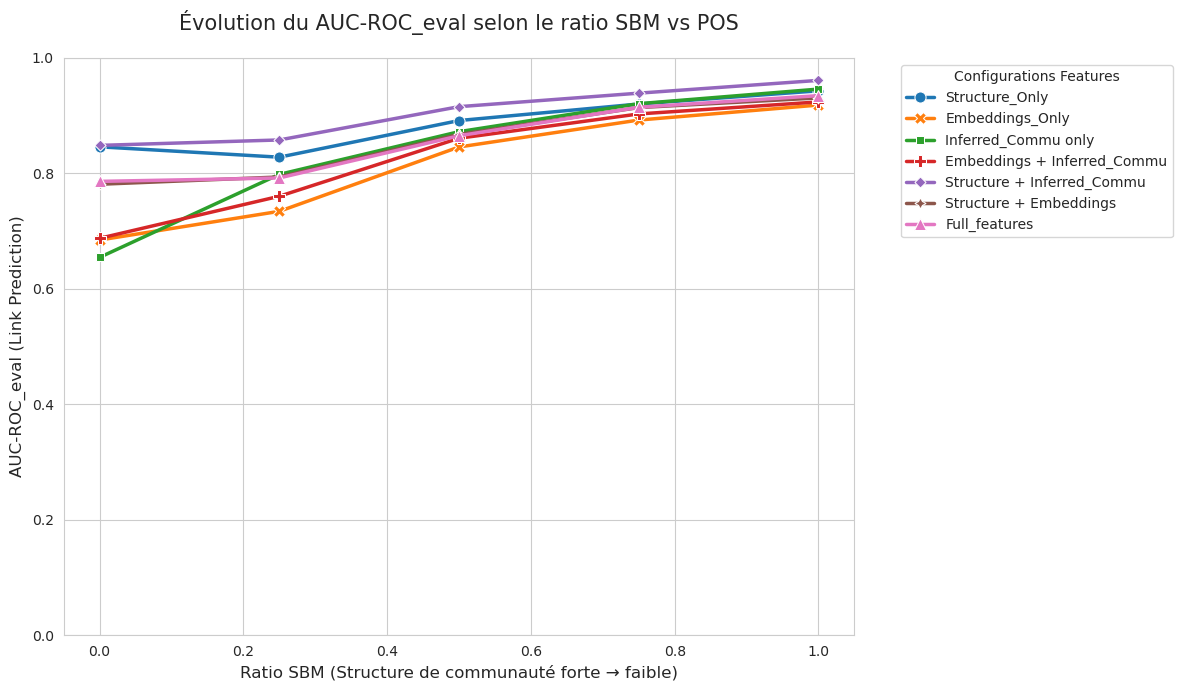

In [8]:
def plot_f1_comparison(df_results, metric="F1-Score"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.00, 1.00) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"artificial_graphs_v2_comparaison_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

plot_f1_comparison(df_compare, metric="AUC-ROC_eval" )

### 1.3 Analyse détaillée des faux positifs, vrais pos, etc ...

In [72]:
df_same_block = dataset[dataset['same_block_reel'] == 1]

# On compare le taux de liens réels (target) selon les voisins communs
results = df_same_block.groupby(df_same_block['cn'] > 0)['target'].mean()

print("Taux de liens réels (p) au sein d'un bloc :")
print(f"Sans voisins communs : {results[False]:.4f}")
print(f"Avec voisins communs : {results[True]:.4f}")

df_same_block_eval = eval_dataset[eval_dataset['same_block_reel'] == 1]
results_eval = df_same_block_eval.groupby(df_same_block_eval['cn'] > 0)['target'].mean()

print("--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(f"Taux réel quand CN = 0 : {results_eval.get(False, 0):.4f}")
print(f"Taux réel quand CN > 0 : {results_eval.get(True, 0):.4f}")


sp_results = df_same_block.groupby('sp')['target'].agg(['mean', 'count'])

print("--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---")
print(f"Probabilité théorique injectée (p) : ~0.75")
print(sp_results)

sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()
sp_exists = df_same_block_eval[df_same_block_eval['sp'] > 0]['target'].mean()

print(f"\nTaux réel quand SP = 0 (aucun chemin) : {sp_zero:.4f}")
print(f"Taux réel quand SP > 0 (chemin existe) : {sp_exists:.4f}")

import pandas as pd
import numpy as np

def analyze_model_deep_dive(X_test, y_test, y_pred, name):
    """
    Analyse consolidée : Matrice de confusion, Communautés et Shortest Path (SP=1).
    """
    # 0. Alignement et préparation
    target = y_test.values if hasattr(y_test, 'values') else y_test
    df_res = pd.DataFrame({
        'target': target,
        'pred': y_pred,
        'same_block': X_test['same_block_reel'].values
    }, index=X_test.index)
    
    # Gestion du SP
    has_sp_col = 'sp' in X_test.columns
    if has_sp_col:
        df_res['sp1'] = (X_test['sp'] == 1).values
    
    total = len(df_res)
    
    # 1. Définition des masques de la matrice de confusion
    tp_m = (df_res['target'] == 1) & (df_res['pred'] == 1)
    fp_m = (df_res['target'] == 0) & (df_res['pred'] == 1)
    fn_m = (df_res['target'] == 1) & (df_res['pred'] == 0)
    tn_m = (df_res['target'] == 0) & (df_res['pred'] == 0)

    # 2. Fonctions utilitaires pour le détail Intra/Inter/SP1
    def get_details(mask):
        count = mask.sum()
        if count == 0: return "0", 0, 0, 0
        intra = (mask & (df_res['same_block'] == 1)).sum()
        inter = (mask & (df_res['same_block'] == 0)).sum()
        sp1 = (mask & df_res['sp1']).sum() if has_sp_col else 0
        return count, intra, inter, sp1

    tp, tp_intra, tp_inter, tp_sp1 = get_details(tp_m)
    fp, fp_intra, fp_inter, fp_sp1 = get_details(fp_m)
    fn, fn_intra, fn_inter, fn_sp1 = get_details(fn_m)
    tn, tn_intra, tn_inter, tn_sp1 = get_details(tn_m)

    # Affichage
    print(f"\n" + "="*60)
    print(f" DEEP DIVE PERFORMANCE : {name} ".center(60, "="))
    print(f"Nombre total de paires : {total}")
    print("-" * 60)

    # SECTION VRAIS POSITIFS
    print(f"VRAIS POSITIFS (TP) : {tp}")
    if tp > 0:
        print(f"  ├─ Intra-bloc : {tp_intra} | Inter-bloc : {tp_inter}")
        if has_sp_col:
            print(f"  └─ Dont déjà connus (SP=1) : {tp_sp1} ({tp_sp1/tp:.1%})")
            print(f"  └─ Trouvés par intelligence (SP!=1) : {tp - tp_sp1}")

    print("-" * 60)

    # SECTION FAUX POSITIFS
    print(f"FAUX POSITIFS (FP) : {fp}")
    if fp > 0:
        print(f"  ├─ Intra-bloc : {fp_intra} (Confusion même bloc)")
        print(f"  ├─ Inter-bloc : {fp_inter} (Erreur sur lien rare)")
        if has_sp_col:
            print(f"  └─ Dont avec SP=1 : {fp_sp1}")

    print("-" * 60)

    # SECTION FAUX NÉGATIFS
    print(f"FAUX NÉGATIFS (FN) : {fn}")
    if fn > 0:
        print(f"  ├─ Intra-bloc : {fn_intra} | Inter-bloc : {fn_inter}")
        if has_sp_col:
            print(f"  └─ Dont connus ratés (SP=1) : {fn_sp1}")

    print("-" * 60)

    # SECTION VRAIS NÉGATIFS
    print(f"VRAIS NÉGATIFS (TN) : {tn}")
    print(f"  └─ Intra-bloc : {tn_intra} | Inter-bloc : {tn_inter}")

    print("-" * 60)

    # SYNTHÈSE SUR L'INCONNU (Intelligence réelle)
    if has_sp_col:
        hidden_links_mask = (df_res['target'] == 1) & (~df_res['sp1'])
        n_hidden = hidden_links_mask.sum()
        if n_hidden > 0:
            tp_hidden = (tp_m & ~df_res['sp1']).sum()
            print(f"SCORE SUR LIENS MASQUÉS (SP!=1) : {tp_hidden}/{n_hidden} ({tp_hidden/n_hidden:.2%})")
            
    # DENSITÉS DE CONTRÔLE
    n_intra_total = (df_res['same_block'] == 1).sum()
    n_inter_total = (df_res['same_block'] == 0).sum()
    print(f"Densités observées : p={ (tp_intra+fn_intra)/n_intra_total:.4f} | q={ (tp_inter+fn_inter)/n_inter_total:.4f}")
    print("="*60)

# Utilisation :
# analyze_predictions_vs_sp1(X_test_s, y_test, preds)


X_test_GT_only = X_test_GT_only.copy()
X_test_GT_only['sp'] = dataset.loc[X_test_GT_only.index, 'sp']
analyze_model_deep_dive(X_test_GT_only, y_test_GT_only, preds_GT_only, "GT Only")

X_test_s = X_test_s.copy()
X_test_s['sp'] = dataset.loc[X_test_s.index, 'sp']
X_test_s['same_block_reel'] = dataset.loc[X_test_s.index, 'same_block_reel']
analyze_model_deep_dive(X_test_s, y_test_s, preds_s, "Structure Only")

Taux de liens réels (p) au sein d'un bloc :
Sans voisins communs : 0.9848
Avec voisins communs : 0.9791
--- ANALYSE DE LA PLUS-VALUE TOPOLOGIQUE (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
Taux réel quand CN = 0 : 0.9420
Taux réel quand CN > 0 : 0.8966
--- ANALYSE DE LA PLUS-VALUE DU SHORTEST PATH (EVAL) ---
Probabilité théorique injectée (p) : ~0.75
    mean  count
sp             
1  1.000   2888
2  0.875    570
3  0.857      7

Taux réel quand SP = 0 (aucun chemin) : nan
Taux réel quand SP > 0 (chemin existe) : 0.8974

============= DEEP DIVE PERFORMANCE : GT Only ==============
Nombre total de paires : 7700
------------------------------------------------------------
VRAIS POSITIFS (TP) : 708
  ├─ Intra-bloc : 708 | Inter-bloc : 0
  └─ Dont déjà connus (SP=1) : 603 (85.2%)
  └─ Trouvés par intelligence (SP!=1) : 105
------------------------------------------------------------
FAUX POSITIFS (FP) : 10
  ├─ Intra-bloc : 10 (Confusion même bloc)
  ├─ Inter-bloc : 0 (Erreur sur

/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_11338/2678378530.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sp_zero = df_same_block[df_same_block_eval['sp'] == 0]['target'].mean()


### 1.4 plots des AP curves

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_ap_comparison(models_dict, X_eval_dict, y_true_dict):
    """
    Trace les courbes Precision-Recall en filtrant dynamiquement les colonnes
    pour éviter les erreurs de mismatch XGBoost.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        trained_features = model.feature_names_in_
        X_filtered = X_eval_dict[name][trained_features]
        
        probs = model.predict_proba(X_filtered)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_true_dict[name], probs)
        ap = average_precision_score(y_true_dict[name], probs)
        
        plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')
    
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision (Précision)')
    plt.title('Comparaison des courbes Precision-Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_ap_comparison(
     {'GroundTruth': model_GT, 'Structure': model_s},
     {'GroundTruth': X_test_GT_only, 'Structure': X_test_s},
     {'GroundTruth': y_test_GT_only, 'Structure': y_test_s}
)

ValueError: continuous-multioutput format is not supported

<Figure size 1000x700 with 0 Axes>

### 1.5 Analyse de variance de probas prédites

In [104]:
def compare_score_distributions(model_gt, X_gt, model_struct, X_struct):
    """
    Compare la variance et la finesse des scores de probabilité entre GT et Structure.
    """
    # 1. Récupération des probabilités (classe 1)
    trained_features_gt = model_gt.feature_names_in_
    trained_features_s = model_struct.feature_names_in_
    X_gt = X_gt[trained_features_gt]
    X_struct = X_struct[trained_features_s]

    probs_gt = model_gt.predict_proba(X_gt)[:, 1]
    probs_st = model_struct.predict_proba(X_struct)[:, 1]
    
    df_compare = pd.DataFrame({
        'prob_gt': probs_gt,
        'prob_st': probs_st,
        'intra': X_gt['same_block_reel'].values
    })

    results = []
    for label, is_intra in [("Intra-Bloc (Même communauté)", 1), ("Inter-Bloc (Communautés diff.)", 0)]:
        subset = df_compare[df_compare['intra'] == is_intra]
        
        results.append({
            "Type": label,
            "Modèle": "Ground Truth",
            "Variance": subset['prob_gt'].var(),
            "Valeurs Uniques": subset['prob_gt'].nunique(),
            "Moyenne": subset['prob_gt'].mean()
        })
        results.append({
            "Type": label,
            "Modèle": "Structure",
            "Variance": subset['prob_st'].var(),
            "Valeurs Uniques": subset['prob_st'].nunique(),
            "Moyenne": subset['prob_st'].mean()
        })

    # Affichage sous forme de tableau propre
    df_res = pd.DataFrame(results)
    print("\n=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===")
    print(df_res.to_string(index=False))
    
    return df_compare

df_ana = compare_score_distributions(model_GT, X_test_GT_only, model_s, X_test_s)


=== ANALYSE DE LA FINESSE DES SCORES (GT vs STRUCTURE) ===
                          Type       Modèle  Variance  Valeurs Uniques  Moyenne
  Intra-Bloc (Même communauté) Ground Truth     0.001              570    0.977
  Intra-Bloc (Même communauté)    Structure     0.088              679    0.104
Inter-Bloc (Communautés diff.) Ground Truth     0.000             5705    0.003
Inter-Bloc (Communautés diff.)    Structure     0.077             4654    0.089


### 1.5 Analyse des communautés inférées

In [99]:
def compute_agreement_ratio(X_test, dataset, algo_col='same_infomap'):
    """
    Calcule le pourcentage de paires où l'inférence est d'accord avec la GT.
    """
    # 1. On récupère la vérité terrain
    y_true = dataset.loc[X_test.index, 'same_block_reel']
    y_inf  = X_test[algo_col]
    
    # 2. On compare
    agreement = (y_true == y_inf).mean()
    
    print(f"Ratio d'accord entre {algo_col} et la réalité : {agreement:.2%}")
    
    # Détail pour ton chercheur :
    # Combien de fois l'algorithme a vu une communauté là où il n'y en a pas (Faux Positifs de structure)
    over_detection = ((y_inf == 1) & (y_true == 0)).sum()
    print(f"  └─ Paires vues 'ensemble' par erreur : {over_detection}")
    
    return agreement

def count_inferred_communities(dataset, algo_prefix='infomap'):
    """
    Compte le nombre de clusters uniques trouvés par un algorithme.
    Ex: algo_prefix='infomap' ira chercher 'infomap_u' et 'infomap_v'.
    """
    col_u = f"{algo_prefix}_u"
    col_v = f"{algo_prefix}_v"
    
    if col_u in X_test.columns and col_v in X_test.columns:
        # On combine les deux colonnes et on compte les valeurs uniques
        all_commus = pd.concat([X_test[col_u], X_test[col_v]])
        n_unique = all_commus.nunique()
        print(f"Nombre de communautés uniques ({algo_prefix}) : {n_unique}")
        return n_unique
    else:
        print(f"Colonnes pour {algo_prefix} introuvables.")
        return None

# Utilisation
n_infomap = count_inferred_communities(dataset, 'infomap')
ratio = compute_agreement_ratio(X_test_s, dataset, 'same_infomap')

Nombre de communautés uniques (infomap) : 100
Ratio d'accord entre same_infomap et la réalité : 100.00%
  └─ Paires vues 'ensemble' par erreur : 0


### 1.6 Exploration visuelle des positions et catégories

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


NameError: name 'PROJECT_ROOT' is not defined

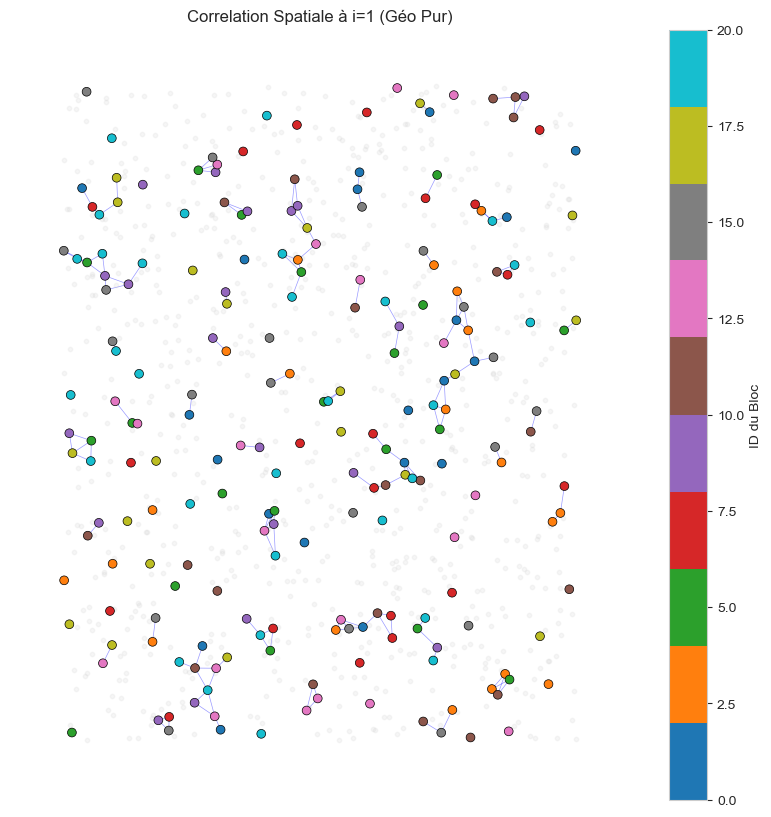

In [81]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.7 Evaluation perfs sur echantillon plus large - OBSOLETE

In [79]:
def generate_extended_eval_data(G, initial_pairs_df, expansion_factor=50, concat = True):
    nodes_list = list(G.nodes())
    num_initial = len(initial_pairs_df)
    target_extra = num_initial * expansion_factor

    existing_pairs = set()
    for u, v in zip(initial_pairs_df['u'], initial_pairs_df['v']):
        existing_pairs.add(tuple(sorted((u, v))))

    extra_pairs_list = []
    current_extra_set = set() 
    
    while len(extra_pairs_list) < target_extra:
        batch_size = min(target_extra - len(extra_pairs_list), 50000)
        random_u = np.random.choice(nodes_list, size=batch_size)
        random_v = np.random.choice(nodes_list, size=batch_size)
        
        for u, v in zip(random_u, random_v):
            if u == v:
                continue
            
            pair = tuple(sorted((u, v)))
            
            if pair not in existing_pairs and pair not in current_extra_set:
                current_extra_set.add(pair)
                extra_pairs_list.append({'u': u, 'v': v, 'target': 0})
            
            if len(extra_pairs_list) >= target_extra:
                break

    extra_df = pd.DataFrame(extra_pairs_list)
    
    if concat: 
        full_df = pd.concat([initial_pairs_df, extra_df], ignore_index=True)
    else:
        full_df = extra_df

    full_df = add_ground_truth_groups(full_df, G)
    
    return full_df

def run_scaling_evaluation(G, base_dataset, experiments_dict, eval_data, factors=[10, 20, 30, 40, 50]):
    all_results = []
    
    for factor in factors:
        print(f"\n" + "="*50)
        print(f" TEST AVEC EXPANSION FACTOR : {factor}")
        print("="*50)
        
        # 1. Génération du dataset d'entraînement étendu
        extended_train_data = generate_extended_eval_data(G, base_dataset, expansion_factor=factor, concat=True)
        
        for exp_name, feat_list in experiments_dict.items():
            print(f"\n🔹 Expérience : {exp_name}")
            
            # 3. Entraînement et Test classique (sur le set étendu)
            stats_train, model, X_test_base, _, y_test_base, _ = gp.train_and_eval_xgboost(extended_train_data, features=feat_list)
            
            # 4. Evaluation
            X_eval_robust = pd.concat([eval_data[feat_list], X_test_base[feat_list]], ignore_index=True)
            y_eval_robust = pd.concat([eval_data["target"], y_test_base], ignore_index=True)
            
            eval_stats = gp.evaluate_model_performance(model, X_eval_robust, y_eval_robust)
            
            # 5. Stockage des résultats
            all_results.append({
                "Factor": factor,
                "Experiment": exp_name,
                "AUC-PR_Test": stats_train["AUC-PR"].iloc[0],
                "AUC-ROC_Eval": eval_stats["AUC-ROC"].iloc[0],
                "F1_Eval": eval_stats["F1-Score"].iloc[0]
            })
            
    return pd.DataFrame(all_results)

In [80]:
G_name = "artificial_graph_sbm_0_00_pos_1_00"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

dataset = dataset_raw[["u", "v", "target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_stress_test = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

experiments = {
    "Ground_Truth_Only_SG": ['same_group'],
    "Ground_Truth_Full": ['group_u', 'group_v', 'same_group'],
}

print(f"Lancement de l'évaluation multi-expériences...")
df_final_results = run_scaling_evaluation(
    G=G, 
    base_dataset=dataset, 
    experiments_dict=experiments, 
    eval_data=eval_stress_test, 
    factors= [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
)

print("\n Analyse terminée.")
print(df_final_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"ANALYSE_Scaling_Full_{G_name}.csv")
df_final_results.to_csv(save_path, index=False)
print(f"Résultats sauvegardés sous : {save_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3500 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib

--- TEST AVEC EXPANSION FACTOR : 0 ---
Modèle A (Same Group Only)...

 RÉSULTATS
[{'F1-Score': 0.9843304843304843, 'AUC-ROC': 0.9844839235811291, 'AP': 0.9833514976974892, 'AUC-PR': 0.9916351580908542}]

 RÉ

In [67]:
import os

# 1. Création du dossier de destination s'il n'existe pas
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)

# 2. Définition du nom du fichier
file_name = f"ANALYSE_EtudeFacteurRatioLiensNonLiens_{G_name}.csv"
file_path = os.path.join(output_dir, file_name)

# 3. Sauvegarde du DataFrame
df_final_results.to_csv(file_path, index=False)

print(f"✅ Dataset sauvegardé avec succès dans : {file_path}")

✅ Dataset sauvegardé avec succès dans : outputs/results/ANALYSE_EtudeFacteurRatioLiensNonLiens_artificial_graph_sbm_1_00_pos_0_00.csv


In [37]:
G_name = "artificial_graph_sbm_0_60_pos_0_40"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_sg = ['same_group']

dataset = dataset_raw[["u", "v","target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_dataset = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

dataset_extended_50 = generate_extended_eval_data(G, df_initial, expansion_factor=50, concat=False)
dataset_extended_10 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)
dataset_extended_20 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)

results =[]
print("DATASET DE BASE, SAME_GROUP ONLY : ")
stats_df, model_a, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth_sg)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })
X_eval = pd.concat([eval_dataset[features_ground_truth_sg], X_test[features_ground_truth_sg]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_a,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET DE BASE, W GROUPS ID : ")
stats_df, model_b, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

X_eval = pd.concat([eval_dataset[features_ground_truth], X_test[features_ground_truth]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_b,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET EXTENDED*50, W GROUPS ID : ")
stats_df, model_c, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset_e, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

"""
gp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])
"""

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3495 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_60_pos_0_40
 Taille : 6990 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
DATASET DE BASE, SAME_GROUP ONLY : 

 RÉSULTATS
[{'F1-Score': 0.5784313725490197, 'AUC-ROC': 0.7020746938976217, 'AP': 0.7099103007031315, 'AUC-PR': 0.8519782405744738}]

 RÉSULTATS D'ÉVALUATION
-------------

'\ngp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])\n'

## 2 - Exploration des Shap values

### 2.1 - Concaténation des Shap_Values pour toutes les valeurs de ratio_sbm

In [24]:
all_summaries = []

for i in np.arange(0, 1.25, 0.25):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbmv2_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    print(f"Type de l'objet : {type(shap_explainer)}")
    print(f"Dimensions des valeurs : {shap_explainer.values.shape}")

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_shapvals_concat = pd.concat(all_summaries)


SHAP Analysis introuvable pour artificial_graph_sbmv2_0_00_pos_1_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (590, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_25_pos_0_75.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (592, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_50_pos_0_50.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (602, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_0_75_pos_0_25.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (600, 23)
SHAP Analysis introuvable pour artificial_graph_sbmv2_1_00_pos_0_00.
Type de l'objet : <class 'shap._explanation.Explanation'>
Dimensions des valeurs : (596, 23)


### 2.2 - Plot des shap_values par sbm_ratio et par feature

Graphique sauvegardé sous : outputs/plots/heatmap_feat_importance_per_ratio_mean_shap.png


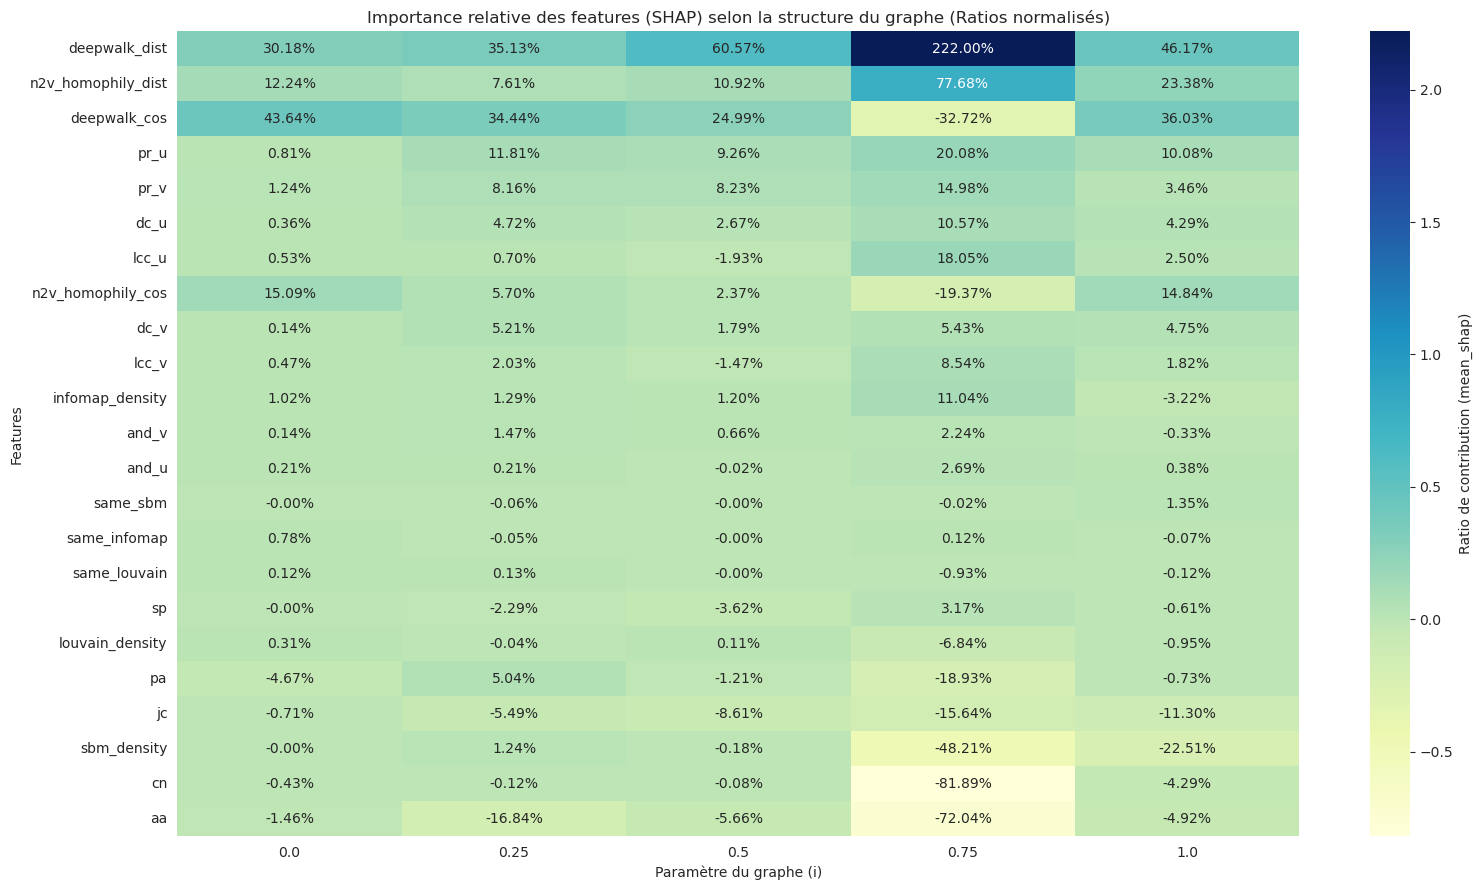

Index(['feature', 'mean_shap', 'mean_abs_shap', 'sbm_param'], dtype='object')
cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr_u, pr_v, lcc_u, lcc_v, and_u, and_v, dc_u, dc_v, louvain_density, same_louvain, infomap_density, same_infomap, sbm_density, same_sbm, n2v_homophily_cos, n2v_homophily_dist, deepwalk_cos, deepwalk_dist, cn, aa, jc, pa, sp, pr

'\nall_distribs = []\nfor i in np.arange(0, 1.05, 0.05):\n    sbm_val = f"{i:.2f}"\n    pos_val = f"{1-i:.2f}"\n    G_name = f"artificial_graph_sbm_{sbm_val.replace(\'.\', \'_\')}_pos_{pos_val.replace(\'.\', \'_\')}"\n    \n    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)\n    X_test = xgboost_data[\'X_test\']\n    y_test = xgboost_data[\'y_test\']\n    \n    pos_sp = X_test[y_test == 1][\'sp\'].value_counts(normalize=True).to_dict()\n    neg_sp = X_test[y_test == 0][\'sp\'].value_counts(normalize=True).to_dict()\n    \n    row = {\'sbm_param\': round(i, 2)}\n    for dist in range(1, 7):\n        row[f\'pos_sp_{dist}\'] = pos_sp.get(dist, 0)\n        row[f\'neg_sp_{dist}\'] = neg_sp.get(dist, 0)\n    \n    row[\'pos_sp_7+\'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)\n    row[\'neg_sp_7+\'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)\n    \n    all_distribs.append(row)\n\ndf_sp_detailed = pd.DataFrame(all_distribs)\n\ncols = [\'sbm_param\'] +

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_abs_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features (SHAP).
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, 
                annot=True,       
                fmt=fmt_type,        
                cmap="YlGnBu",    
                cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features (SHAP) selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()

    filename = f"outputs/plots/heatmap_feat_importance_per_ratio_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé sous : {filename}")
    plt.show()

plot_feature_importance_evolution(df_shapvals_concat, metric="mean_shap", as_ratio=True)
print(df_shapvals_concat.columns)
features_list = df_shapvals_concat['feature']
print(", ".join(map(str, features_list)))

"""
all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _,_, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))
"""

### 2.3 - Exploration du ranking des SHAP vals des features sur chaque paire (voir si qq métriques on avg pas ouf perfs fort sur qq paires) 

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_0_00_pos_1_00
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_train_artificial_graph_sbm_0_00_pos_1_00
 Taille : 32725 lignes, 29 colonnes.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_eval_artificial_graph_sbm_0_00_pos_1_00
 Taille : 26775 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
SHAP Analysis introuvable pour artificial_gra

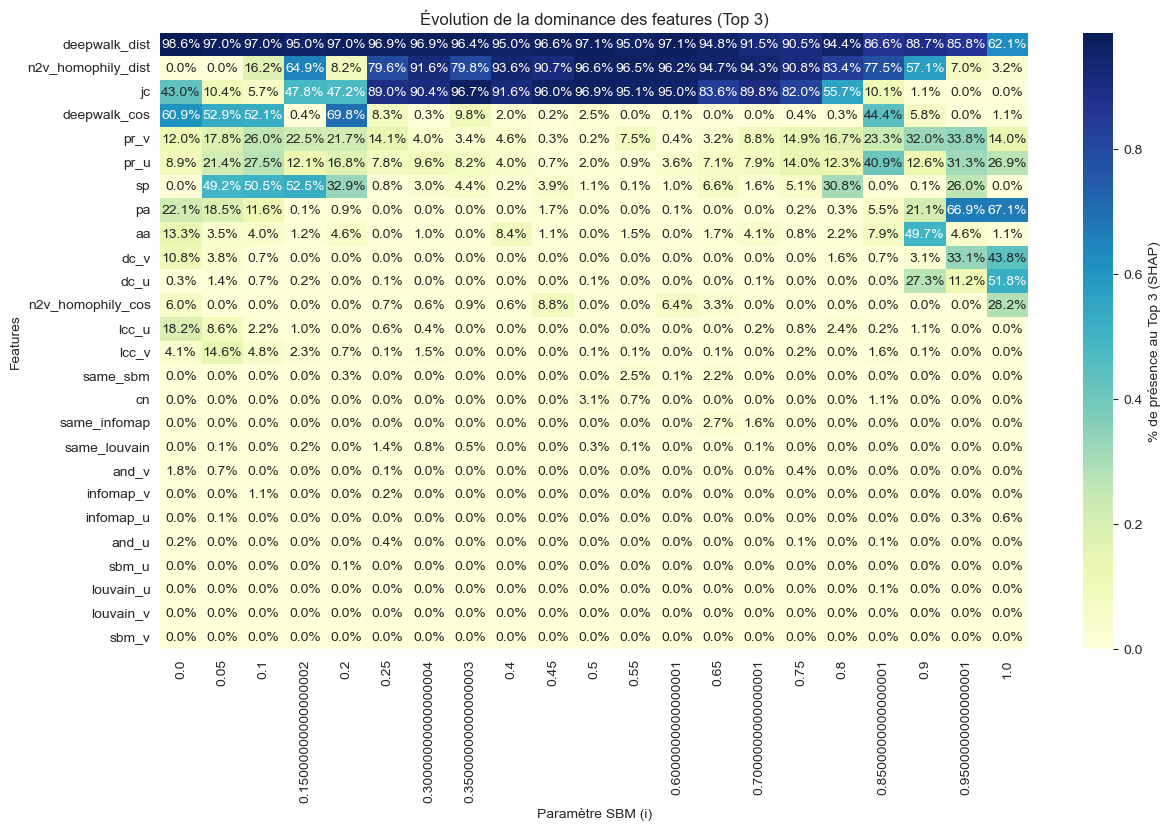

In [66]:
def plot_feature_importance_heatmap(df_results, output_filename="heatmap_shap_percentage_presence_top_k.png"):
    """
    Génère une heatmap dynamique selon le ratio présent dans le DataFrame.
    """
    ratio_col = [c for c in df_results.columns if '_ratio' in c][0]
    k_val = ratio_col.replace('top', '').replace('_ratio', '')

    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=ratio_col)
    
    heatmap_data['avg'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('avg', ascending=False).drop(columns='avg')

    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt=".1%", 
                cmap="YlGnBu", 
                cbar_kws={'label': f'% de présence au Top {k_val} (SHAP)'})

    plt.title(f"Évolution de la dominance des features (Top {k_val})")
    plt.xlabel("Paramètre SBM (i)")
    plt.ylabel("Features")
    
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig(f"outputs/plots/{output_filename}", dpi=300, bbox_inches='tight')
    plt.show()


results_list = []
k_target = 3 

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    try:
        _, _, _, xgboost_data, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
        vals = shap_explainer.values
        if isinstance(vals, list): vals = vals[1]

        df_ranks = gp.calculate_feature_rankings(vals, xgboost_data['X_test'].columns, top_k=k_target, plot=False)
        
        top_k_sum = df_ranks.iloc[0:k_target, :].sum(axis=0)
        
        for feat_name, val in top_k_sum.items():
            results_list.append({
                'sbm_param': i,
                'feature': feat_name,
                f'top{k_target}_ratio': val / 100  
            })
            
    except Exception as e:
        print(f"Skipping {G_name} due to error: {e}")

df_shap_rankings = pd.DataFrame(results_list)

plot_feature_importance_heatmap(df_shap_rankings)

## 3 - Exploration des features et groupes de features

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_00.png


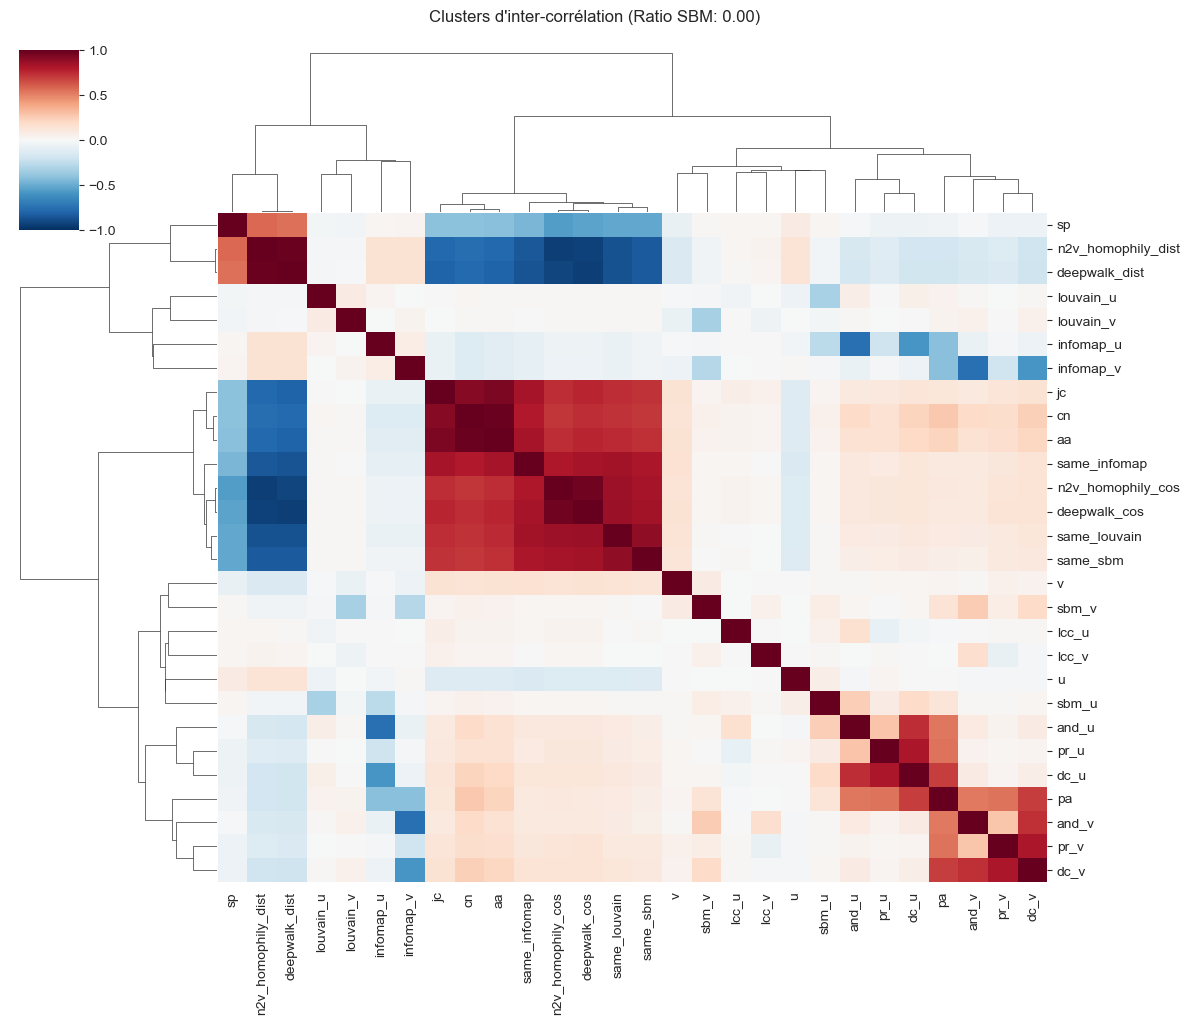

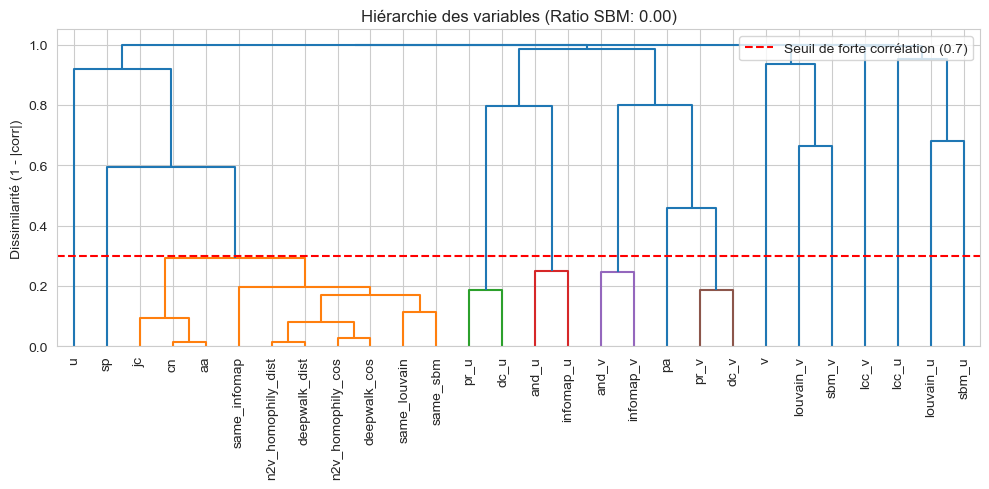

SHAP Analysis introuvable pour artificial_graph_sbm_0_25_pos_0_75.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_25.png


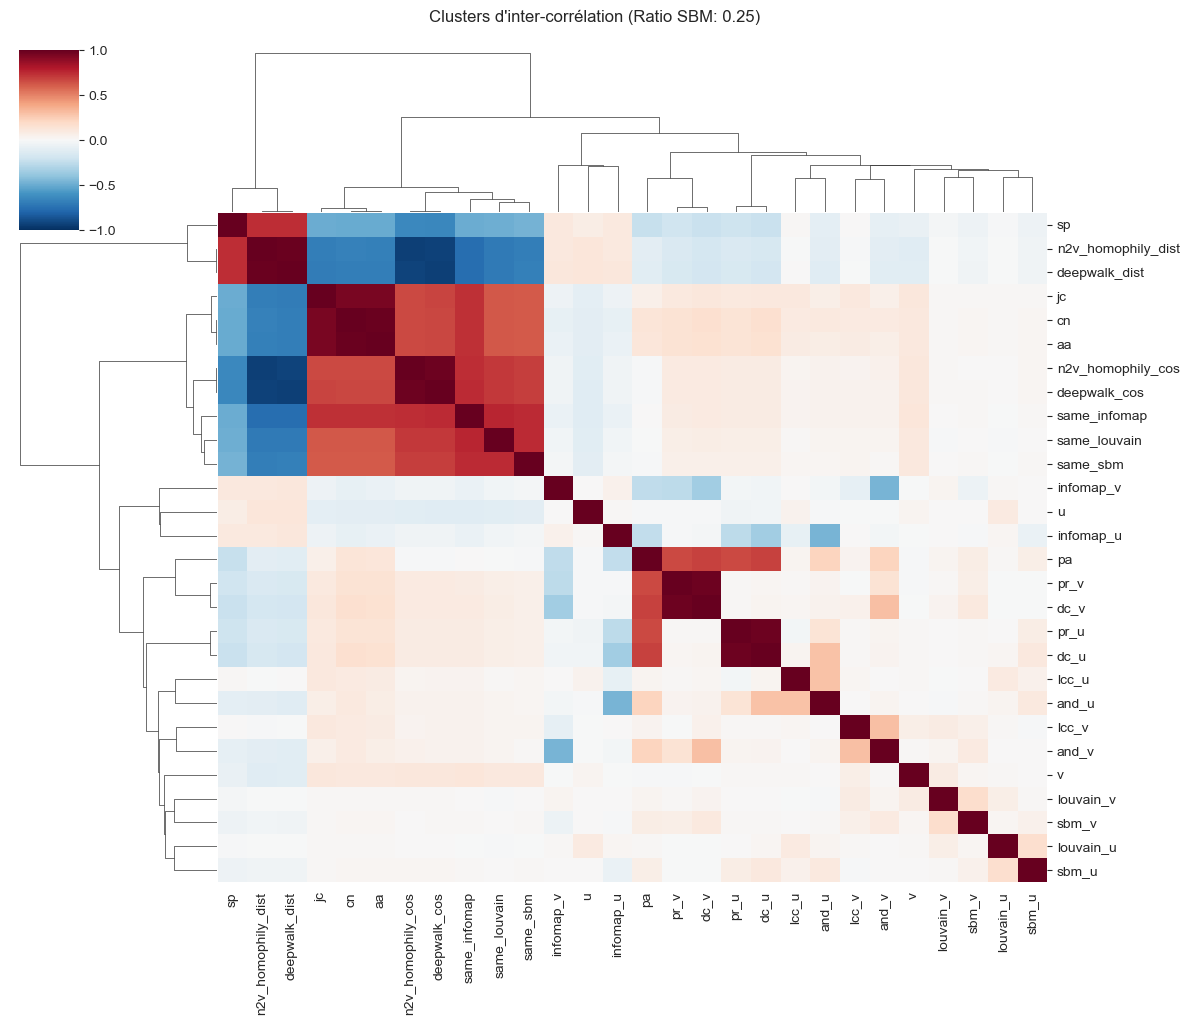

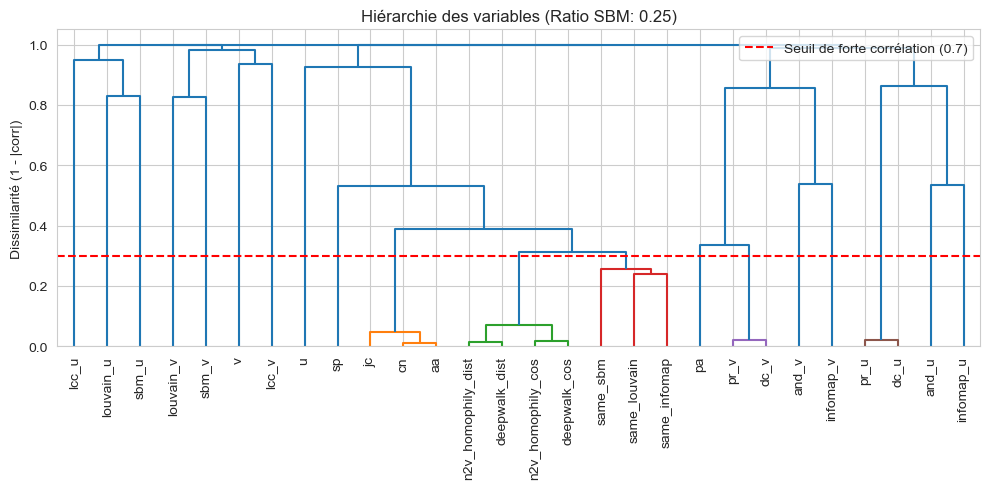

SHAP Analysis introuvable pour artificial_graph_sbm_0_50_pos_0_50.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_50.png


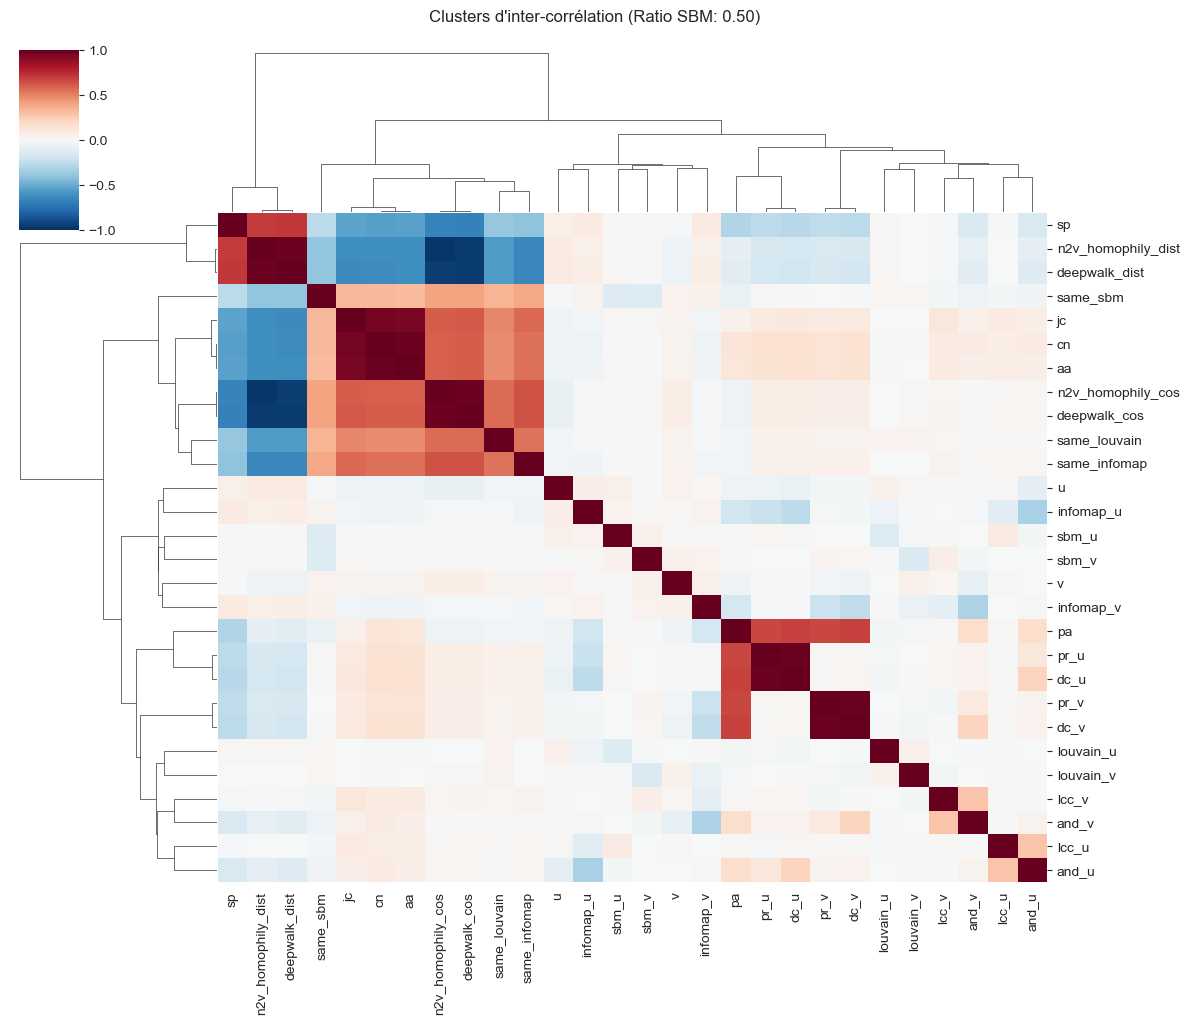

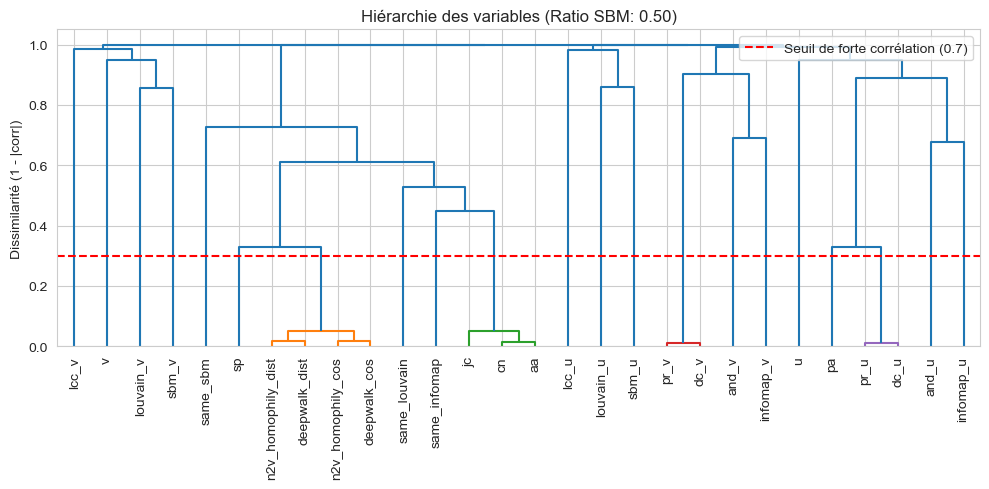

SHAP Analysis introuvable pour artificial_graph_sbm_0_75_pos_0_25.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_0_75.png


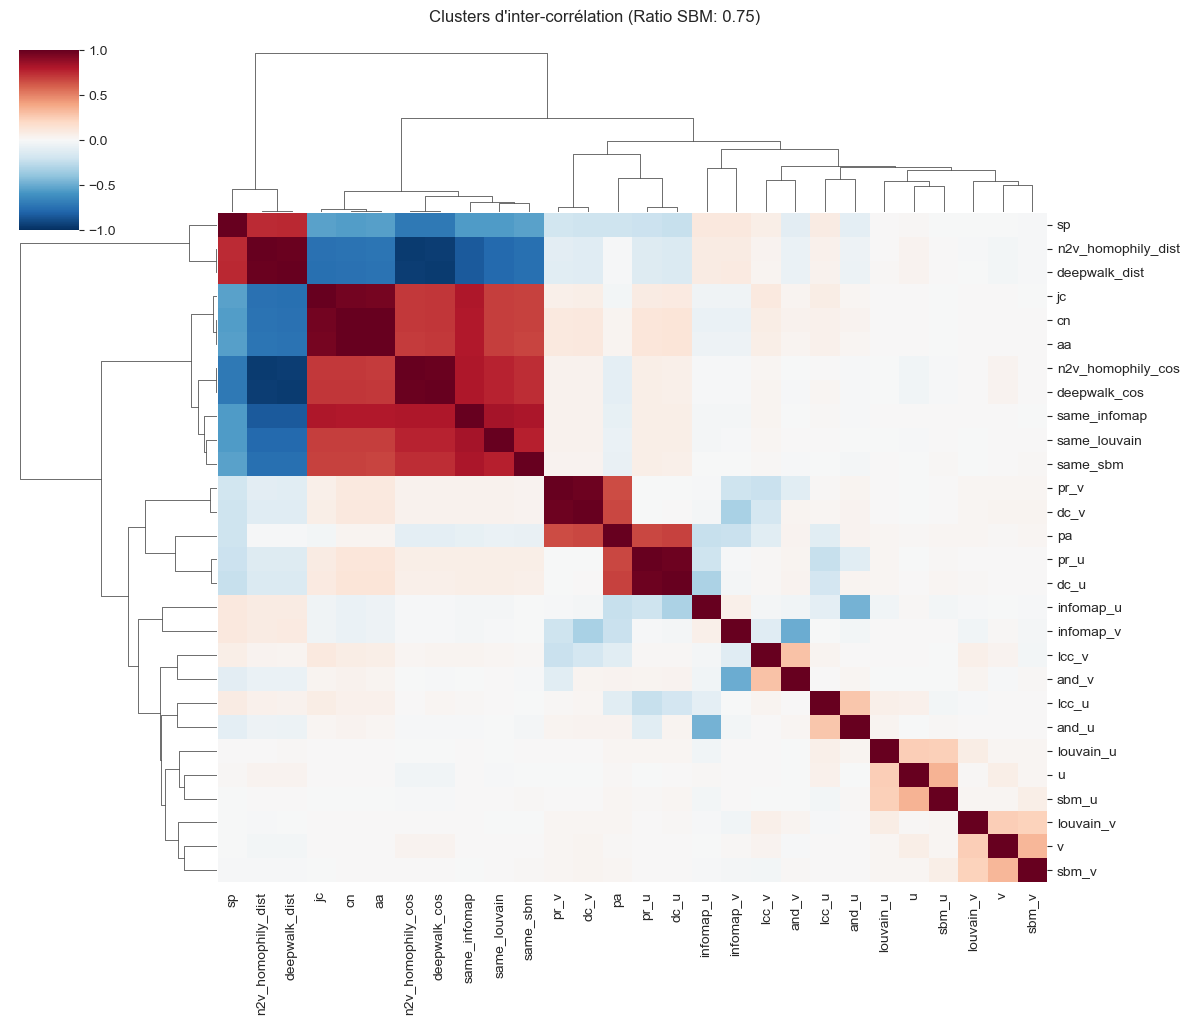

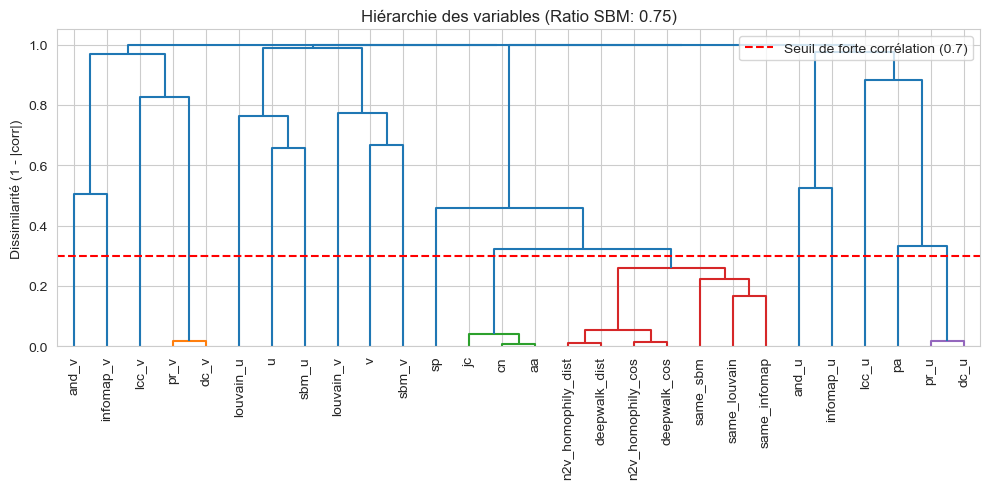

SHAP Analysis introuvable pour artificial_graph_sbm_1_00_pos_0_00.
Graphique sauvegardé : outputs/plots/correlation_clustermap_sbm_1_00.png


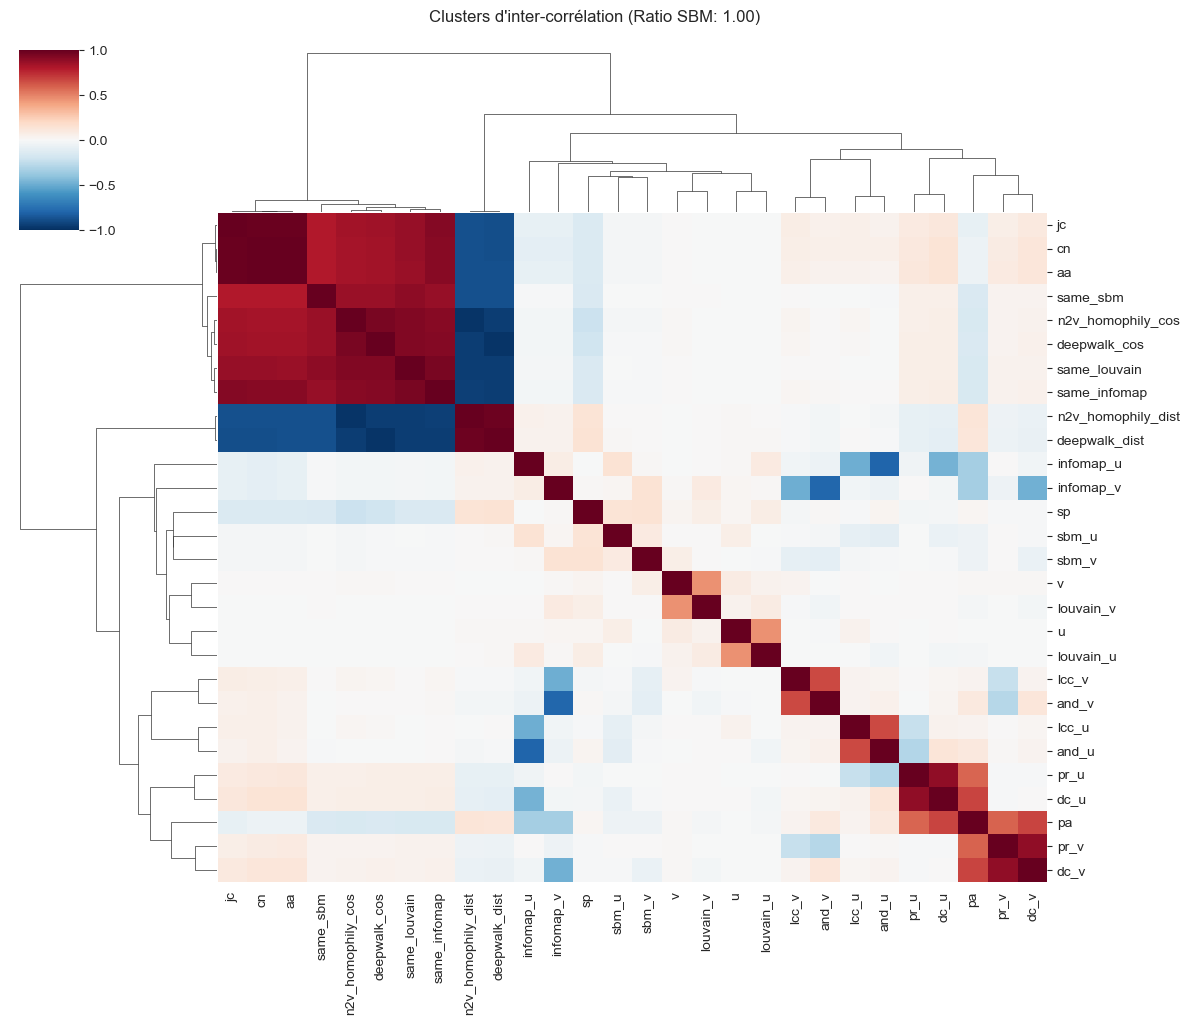

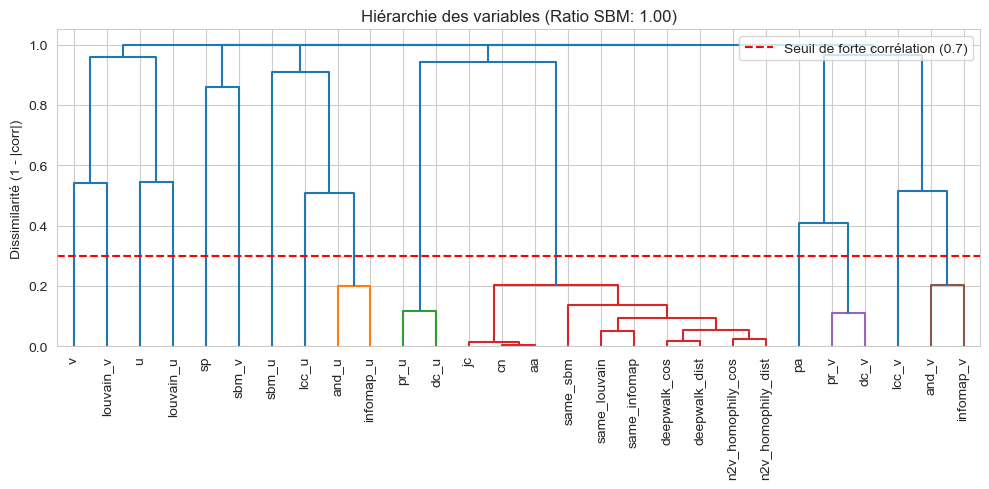

In [82]:
# On garde tes groupes pour l'analyse
group_mapping = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Communities": ['sbm_u', 'sbm_v', 'same_sbm', 'infomap_u', 'infomap_v', 'same_infomap', "louvain_u", "louvain_v", "same_louvain"],
    "Groupe_Embeddings": ['n2v_homophily_cos', 'n2v_homophily_dist', 'deepwalk_cos', 'deepwalk_dist']
}

output_folder = "outputs/plots"
os.makedirs(output_folder, exist_ok=True)

ratios = np.arange(0, 1.05, 0.25) # On réduit le pas pour les plots de clusters

for i in ratios:
    sbm_val_str = f"{i:.2f}"
    pos_val_str = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val_str.replace('.', '_')}_pos_{pos_val_str.replace('.', '_')}"
    
    _, dataset_train, _, _, _, _ = gp.load_all_data_for_graph(G_name)
    features = [c for c in dataset_train.columns if c != 'target']
    df_features = dataset_train[features]
    
    # --- CALCUL DE LA MATRICE DE CORRÉLATION ---
    corr_matrix = df_features.corr(method='pearson')
    
    # --- PLOT 1 : CLUSTERMAP (La vue d'ensemble) ---
    # Combine la heatmap et le dendrogramme
    g = sns.clustermap(corr_matrix, 
                       method='complete', 
                       cmap='RdBu_r', 
                       vmin=-1, vmax=1,
                       figsize=(12, 10))
    g.fig.suptitle(f"Clusters d'inter-corrélation (Ratio SBM: {sbm_val_str})", y=1.02)
    
    save_path = os.path.join(output_folder, f"correlation_clustermap_sbm_{sbm_val_str.replace('.', '_')}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Graphique sauvegardé : {save_path}")

    plt.show()


    # --- PLOT 2 : DENDROGRAMME PUR (Focus structure) ---
    plt.figure(figsize=(10, 5))
    # Distance = 1 - valeur absolue de la corrélation (pour regrouper corr+ et corr-)
    dissimilarity = 1 - np.abs(corr_matrix)
    # squareform pour transformer en vecteur de distance
    Z = hierarchy.linkage(squareform(dissimilarity), method='complete')
    
    hierarchy.dendrogram(Z, labels=features, leaf_rotation=90, color_threshold=0.3)
    plt.axhline(y=0.3, color='r', linestyle='--', label='Seuil de forte corrélation (0.7)')
    plt.title(f"Hiérarchie des variables (Ratio SBM: {sbm_val_str})")
    plt.ylabel("Dissimilarité (1 - |corr|)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4 - Other

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


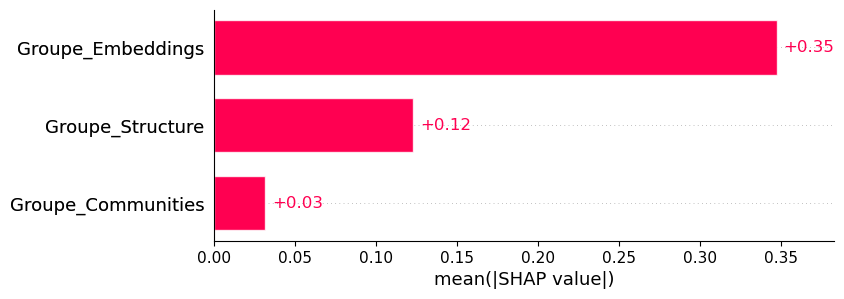


--- SHAP Bar Plot (Absolute) ---


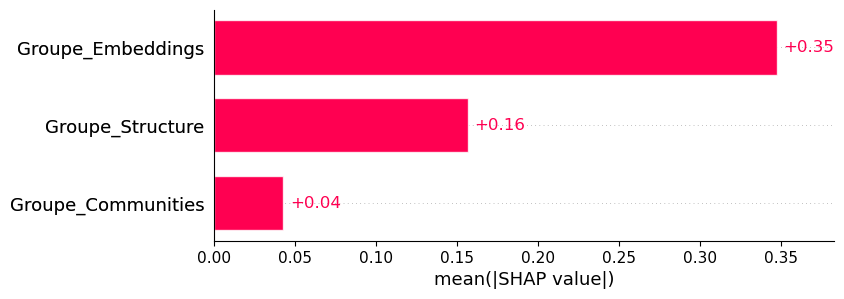


--- SHAP Custom Analysis ---


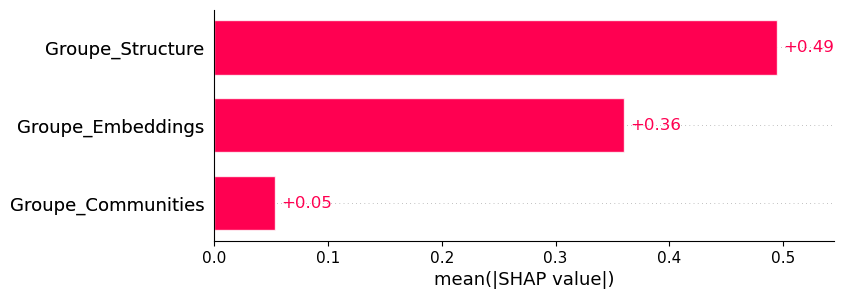


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


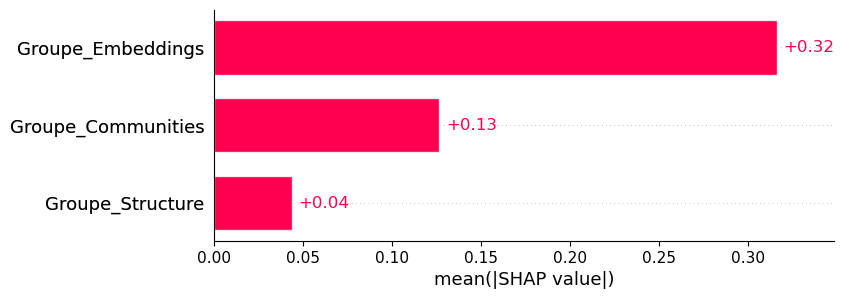


--- SHAP Bar Plot (Absolute) ---


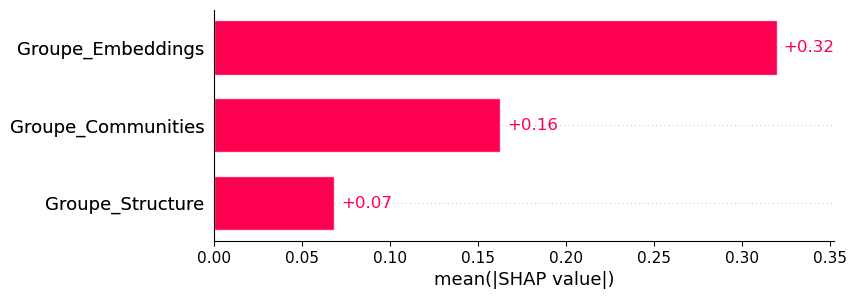


--- SHAP Custom Analysis ---


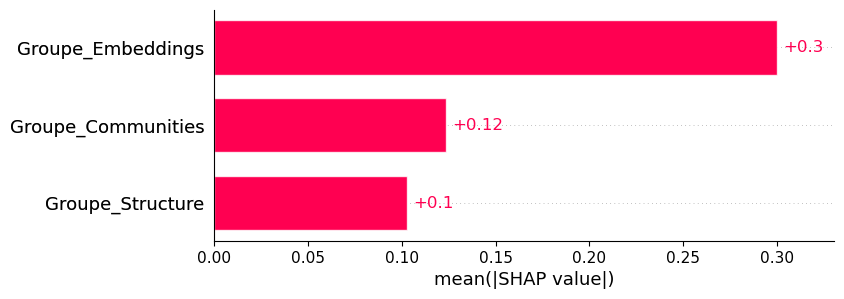


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
def xgboost_shap_pipeline(dataset, name):
    exclude = ['u', 'v', 'target', 'label']
    features = [col for col in dataset.columns if col not in exclude]
    
    results, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset, features=features)

    data_to_save = {
        "results": results,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "y_test": y_test,
        "y_train": y_train
    }

    print("Sauvegarde des données XGBoost (model,X1yTest et Train)")
    gp.loadsave_data_joblib(data=data_to_save,filename=f"xgboost_data_{name}.joblib", mode="save")

    print("\n RÉSULTATS")
    print(results.to_string(index=False))

    print("\n Shapley va ! Lu.")

    shap_explanation = gp.analyze_with_shap(model, X_test)
    print("Sauvegarde de l'analyse SHAP")
    gp.loadsave_data_joblib(data=shap_explanation, filename = f"shap_explainer_{name}.joblib", mode="save")

xgboost_shap_pipeline(dataset_sbm_1_true_groups, "TEST_W_REAL_GROUPS_SBM_1")
xgboost_shap_pipeline(dataset_sbm_0_5_true_groups, "TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


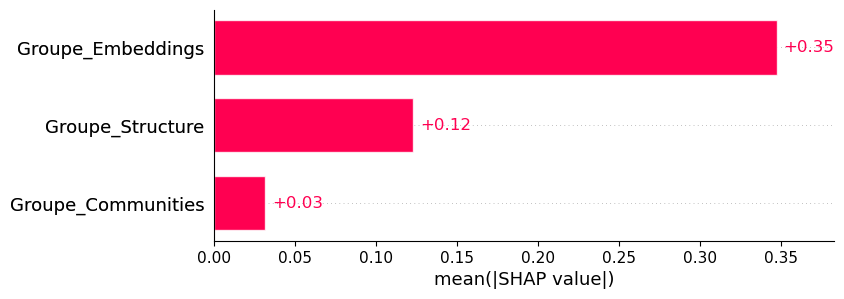


--- SHAP Bar Plot (Absolute) ---


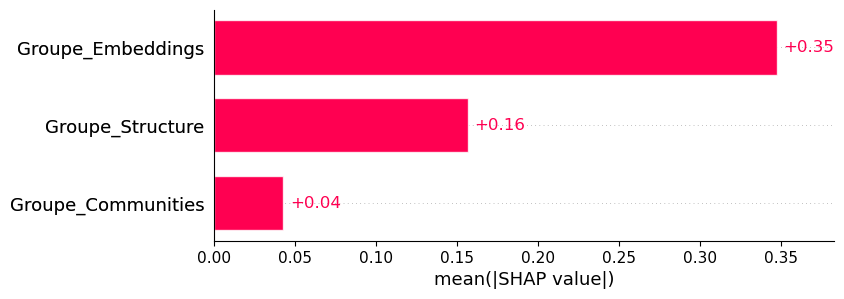


--- SHAP Custom Analysis ---


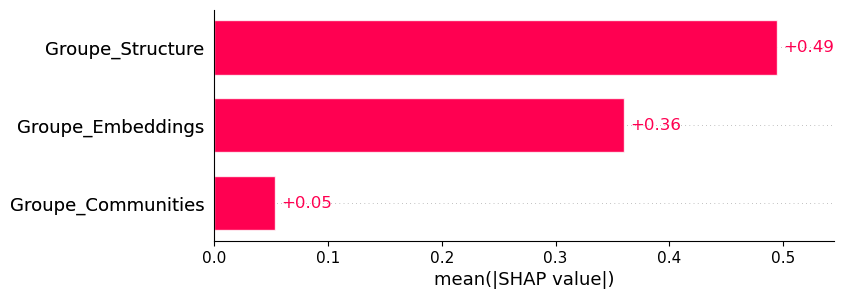


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


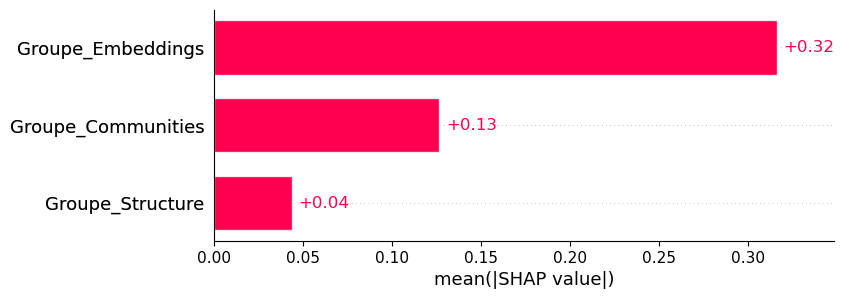


--- SHAP Bar Plot (Absolute) ---


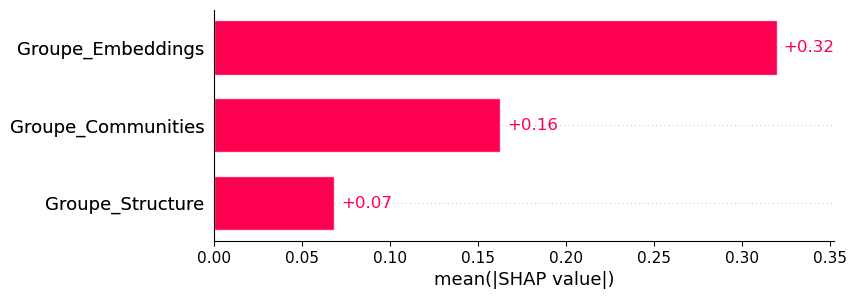


--- SHAP Custom Analysis ---


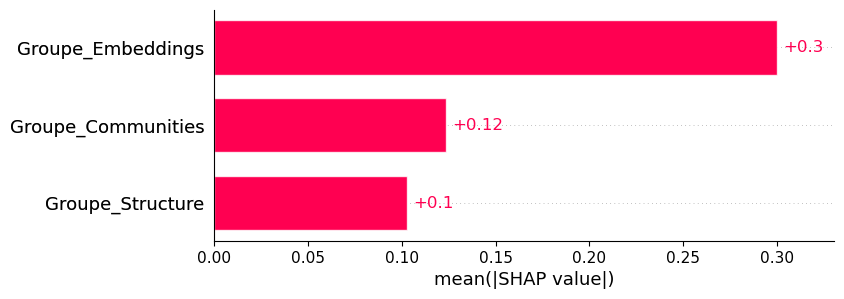


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
gp.evaluate("TEST_W_REAL_GROUPS_SBM_1", display = True)
gp.evaluate("TEST_W_REAL_GROUPS_SBM_0_5", display = True)

In [4]:
gp.display_shap("TEST_W_REAL_GROUPS_SBM_1")
gp.display_shap("TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib


1

In [30]:
dataset, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph("TEST_W_REAL_GROUPS_SBM_0_5")
dataset_base, xgboost_data_base, shap_explainer_base, shap_analysis_base = gp.load_all_data_for_graph("artificial_graph_sbm_0_50_pos_0_50")

gp.evaluate_model_performance(model = xgboost_data["model"], X_test = xgboost_data["X_test"], y_test = xgboost_data["y_test"], plot = False)
gp.evaluate_model_performance(model = xgboost_data_base["model"], X_test = xgboost_data_base["X_test"], y_test = xgboost_data_base["y_test"], plot = False)

print(dataset.head(2))
print(dataset_base.head(2))


dataset_cleared = dataset.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)
dataset_base_cleared = dataset_base.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)

print(dataset_cleared.head(2))
print(dataset_base_cleared.head(2))


all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_cleared)
all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_base)

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_TEST_W_REAL_GROUPS_SBM_0_5
 Taille : 6988 lignes, 23 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_50_pos_0_50
 Taille : 6988 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [43]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

all_results = []

for i in np.arange(0, 1.05, 0.05):
    
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    
    print(f"\n--- Évaluation : SBM {sbm_val} | POS {pos_val} ---")
    
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)

    print(dataset.columns)

    stats_df = gp.evaluate_model_performance(model=xgboost_data["model"], X_test=xgboost_data["X_test"], y_test=xgboost_data["y_test"], plot=False)
    
    all_results.append({
        "Graph_Name": G_name,
        "SBM_Ratio": i,
        "F1-Score": stats_df["F1-Score"].iloc[0]
    })

df_final_results = pd.DataFrame(all_results)

print("\n--- TABLEAU RÉCAPITULATIF ---")
print(df_final_results)

output_dir = os.path.join("outputs", "plots")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "artificial_graphs_recapitulatif_performances_f1.csv")

df_final_results.to_csv(output_path, index=False)

print(f"\n Tableau récapitulatif sauvegardé ici : {output_path}")


--- Évaluation : SBM 0.00 | POS 1.00 ---
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u',
       'community_v', 'same_community', 'infomap_u', 'infomap